## 1. Imports & global settings


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


### 1.1 Analysis parameters

These settings are applied to **all** parquets.


In [2]:
# Segmentation and preprocessing parameters (applied to all parquets)
GAP_THRESHOLD_SECONDS = 3600   # split segment if gap > 1 hour
MIN_POINTS_PER_SEGMENT = 100   # minimum rows per segment
EMA_ALPHA = 0.1                # smoothing factor (0 < alpha <= 1)


## 2. Signal mapping

Mapping between `signal_id` and human-readable signal names and metadata.


In [6]:
mapping = {
    'signal_id': [8890,9620,9619,11247,11333,11331,16769,15454,15453,16679,14156,14154,
                  26499,30654,30653,29296,29388,29386,16796,24141,24140,25120,25207,25205,
                  18263,19318,19317,21058,21145,21143],
    'measurement_unit': ['MW','', '', '%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar'],
    'type_id': ['measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)'],
    'plant': ['KSL']*30,
    'stage': ['Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg'],
    'machine_group': ['MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG3','MG3','MG3','MG3','MG3','MG3'],
    'signal_name': ['active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream'],
    'description': [
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
    ]
}

df_mapping = pd.DataFrame(mapping)
df_mapping.head()

,signal_id,measurement_unit,type_id,plant,stage,machine_group,signal_name,description
0,8890,MW,measurement (analog),KSL,Mapragg,MG1,active_power,Active power measurement
1,9620,,Bool,KSL,Mapragg,MG1,ball_valve_closed,Ball valve position rotating body closed (true...
2,9619,,Bool,KSL,Mapragg,MG1,ball_valve_open,Ball valve position rotating body open (true i...
3,11247,%,measurement (analog),KSL,Mapragg,MG1,guide_vane_position,Guide vane position measurement
4,11333,bar,measurement (analog),KSL,Mapragg,MG1,water_pressure_downstream,water pressure downstream of the turbine


## 3. Helper functions

Functions for gap analysis, segmentation, extraction, smoothing and correlation.


In [7]:
def analyze_gaps(df, time_col='ts_sec'):
    """Print basic gap statistics for a given dataframe."""
    arr = np.sort(df[time_col].unique())
    if len(arr) < 2:
        print('Not enough points for gap analysis.')
        return
    diffs = np.diff(arr)
    print('Gap analysis:')
    print(f'  Min gap: {diffs.min():.2f} s')
    print(f'  Max gap: {diffs.max():.2f} s')
    print(f'  Mean gap: {diffs.mean():.2f} s')
    print(f'  Median gap: {np.median(diffs):.2f} s')
    print(f'  95th percentile: {np.percentile(diffs, 95):.2f} s')
    print(f'  99th percentile: {np.percentile(diffs, 99):.2f} s')


In [8]:
def create_synchronized_segments(df, gap_threshold_seconds=3600, min_points=1):
    """Split dataframe into segments based on gaps in `ts_sec`.

    Parameters
    ----------
    df : DataFrame with column 'ts_sec'
    gap_threshold_seconds : float, gap > threshold triggers a new segment
    min_points : int, minimum number of rows to keep a segment
    """
    df_sorted = df.sort_values('ts_sec').reset_index(drop=True)
    all_ts = np.sort(df_sorted['ts_sec'].unique())
    if len(all_ts) == 0:
        return []
    if len(all_ts) == 1:
        return [df_sorted]

    diffs = np.diff(all_ts)
    gap_indices = np.where(diffs > gap_threshold_seconds)[0]

    segments = []
    start_idx = 0

    def add_segment(seg):
        if len(seg) >= min_points:
            segments.append(seg)

    for gap_idx in gap_indices:
        start_time = all_ts[start_idx]
        end_time = all_ts[gap_idx]
        seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                        (df_sorted['ts_sec'] <= end_time)].copy()
        add_segment(seg)
        start_idx = gap_idx + 1

    # final segment
    start_time = all_ts[start_idx]
    end_time = all_ts[-1]
    seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                    (df_sorted['ts_sec'] <= end_time)].copy()
    add_segment(seg)
    return segments


In [9]:
def extract_and_normalize(segments, signal_name):
    """Extract given signal from each segment and normalize time so t0 = 0.

    Returns a list of dataframes with an extra column 't0_sec'.
    """
    result = []
    for seg in segments:
        sub = seg[seg['signal_name'] == signal_name].copy()
        if not sub.empty:
            segment_start = seg['ts_sec'].min()
            sub['t0_sec'] = sub['ts_sec'] - segment_start

            result.append(sub)
    return result


In [10]:
def get_sampling_rate(df_signal):
    """Estimate sampling rate (Hz) and average interval (s) for a signal segment."""
    if len(df_signal) < 2:
        return None, None
    df_signal = df_signal.sort_values('ts_sec')
    time_diff = np.diff(df_signal['ts_sec'].values)
    avg_interval = np.mean(time_diff)
    sampling_rate = 1.0 / avg_interval if avg_interval != 0 else None
    return sampling_rate, avg_interval


In [11]:
def apply_ffill_to_segments(segments):
    """Apply forward fill to each dataframe in a list of segments."""
    return [seg.ffill() for seg in segments]


In [12]:
def ema(data, alpha):
    """Compute Exponential Moving Average for a 1D array-like."""
    data = np.asarray(data, dtype=float)
    if data.size == 0:
        return data
    ema_values = np.zeros_like(data, dtype=float)
    ema_values[0] = data[0]
    for i in range(1, len(data)):
        ema_values[i] = alpha * data[i] + (1 - alpha) * ema_values[i - 1]
    return ema_values


In [13]:
def apply_ema_to_value(segments, alpha):
    """Apply EMA to the 'value' column in each segment."""
    result = []
    for seg in segments:
        seg_ema = seg.copy()
        seg_ema['value'] = ema(seg['value'].values, alpha)
        result.append(seg_ema)
    return result


## 4. Discover parquet files

We look for all `*_real_measurements.parquet` files in the current directory.


In [14]:
parquet_files = sorted(
    [os.path.join('data', f) for f in os.listdir('data')
     if f.endswith('.parquet') and 'real_measurements' in f]
)


print('Found parquet files:')
for f in parquet_files:
    print('  -', f)


Found parquet files:
  - data/Mapragg_MG1_testing_real_measurements.parquet
  - data/Mapragg_MG1_training_real_measurements.parquet
  - data/Mapragg_MG2_testing_real_measurements.parquet
  - data/Mapragg_MG2_training_real_measurements.parquet
  - data/Mapragg_MG3_testing_real_measurements.parquet
  - data/Mapragg_MG3_training_real_measurements.parquet
  - data/Sarelli_MG1_testing_real_measurements.parquet
  - data/Sarelli_MG1_training_real_measurements.parquet
  - data/Sarelli_MG2_testing_real_measurements.parquet
  - data/Sarelli_MG2_training_real_measurements.parquet


In [15]:
# -----------------------------
# BUILD all_raw FROM PARQUETS
# -----------------------------
all_raw = {}

for f in parquet_files:
    print("Loading:", f)
    df = pd.read_parquet(f)

    # Ensure expected columns exist
    needed = {"ts", "signal_id", "value"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{f} missing required columns: {needed - set(df.columns)}")

    # Convert timestamp to seconds float
    df["ts"] = pd.to_datetime(df["ts"])
    df["ts_sec"] = df["ts"].astype("int64") / 1e9    # convert ns → sec (float)
    
    # Merge with mapping
    dfm = df.merge(df_mapping, on="signal_id", how="left")

    # Structure storage
    all_raw[f] = {
        "stage": dfm["stage"].iloc[0],
        "machine_group": dfm["machine_group"].iloc[0],
        "dataset_type": "raw",
        "signals": {}
    }

    # Build raw arrays per signal_name
    for sig in df_mapping.signal_name.unique():
        sdf = dfm[dfm.signal_name == sig].sort_values("ts_sec")

        all_raw[f]["signals"][sig] = {
            "ts_sec": sdf["ts_sec"].to_numpy(),
            "value":  sdf["value"].to_numpy(),
        }

print("\nFinished building all_raw.")


Loading: data/Mapragg_MG1_testing_real_measurements.parquet
Loading: data/Mapragg_MG1_training_real_measurements.parquet
Loading: data/Mapragg_MG2_testing_real_measurements.parquet
Loading: data/Mapragg_MG2_training_real_measurements.parquet
Loading: data/Mapragg_MG3_testing_real_measurements.parquet
Loading: data/Mapragg_MG3_training_real_measurements.parquet
Loading: data/Sarelli_MG1_testing_real_measurements.parquet
Loading: data/Sarelli_MG1_training_real_measurements.parquet
Loading: data/Sarelli_MG2_testing_real_measurements.parquet
Loading: data/Sarelli_MG2_training_real_measurements.parquet

Finished building all_raw.


In [16]:
def show_raw_file(filename):

    if filename not in all_raw:
        print("No raw data for:", filename)
        return

    group = all_raw[filename]

    stage         = group["stage"]
    machine_group = group["machine_group"]
    dataset_type  = group["dataset_type"]

    signals_to_plot = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    # Units corresponding to signals
    units = ["[W]", "[%]", "[bar]", "[bar]", "[-]", "[-]"]

    fig, axes = plt.subplots(
        len(signals_to_plot), 1,
        figsize=(12, 2.6 * len(signals_to_plot)),
        sharex=False
    )

    if len(signals_to_plot) == 1:
        axes = [axes]

    # Use matplotlib's default color cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for ax, sig, unit, color in zip(axes, signals_to_plot, units, color_cycle):

        raw = group["signals"][sig]

        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(raw["ts_sec"], raw["value"], ".", markersize=5, color=color)
        else:
            ax.plot(raw["ts_sec"], raw["value"], linewidth=1, color=color)

        pretty_sig = sig.replace("_", " ").capitalize()

        ax.set_ylabel(f"{pretty_sig} {unit}", fontsize=9)
        ax.set_xlabel("time [s]", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{filename} — RAW DATA\n",
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    plt.show()



In [17]:
raw_file_dropdown = widgets.Dropdown(
    options=parquet_files,
    description="Parquet"
)

raw_out = widgets.interactive_output(
    show_raw_file,
    {"filename": raw_file_dropdown}
)

display(VBox([raw_file_dropdown, raw_out]))


## 5. Main loop over parquets

For each parquet we perform the full analysis pipeline, completely independently.


In [18]:
# ======================================================================
# STORAGE FOR FINAL SAMPLING RATE SUMMARY (ALL PARQUETS)
# ======================================================================
all_sampling_stats = {}

# ======================================================================
# MAIN PARQUET LOOP
# ======================================================================
all_segments = {}   # dictionary to keep segments for interactive plotting

for path in parquet_files:
    print('\n' + '='*80)
    print(f'Analyzing file: {path}')
    print('='*80)

    # Try to infer stage / machine group / dataset type from filename
    base = os.path.basename(path)
    name_no_ext = base.replace('.parquet', '')
    parts = name_no_ext.split('_')
    stage = parts[0] if len(parts) > 0 else 'UnknownStage'
    machine_group = parts[1] if len(parts) > 1 else 'UnknownMG'
    dataset_type = parts[2] if len(parts) > 2 else 'UnknownType'

    print(f'Stage: {stage}, Machine group: {machine_group}, Dataset type: {dataset_type}')

    # ---------------- Load parquet ----------------
    df = pd.read_parquet(path, engine='pyarrow')
    print('Raw dataframe shape:', df.shape)

    if 'ts' not in df.columns:
        raise ValueError(f"Column 'ts' not found in {path}")

    if not pd.api.types.is_datetime64_any_dtype(df['ts']):
        df['ts'] = pd.to_datetime(df['ts'])
    if getattr(df['ts'].dt, "tz", None) is not None:
        df['ts'] = df['ts'].dt.tz_convert(None)

    if 'signal_id' not in df.columns:
        raise ValueError(f"Column 'signal_id' not found in {path}")

    df = df.merge(df_mapping, on='signal_id', how='inner')
    print('After mapping, shape:', df.shape)

    df['ts_sec'] = (df['ts'] - df['ts'].min()).dt.total_seconds()

    if stage in df_mapping['stage'].unique().tolist():
        df = df[df['stage'] == stage]
    if machine_group in df_mapping['machine_group'].unique().tolist():
        df = df[df['machine_group'] == machine_group]

    print('After filtering by mapping stage/MG, shape:', df.shape)

    if df.empty:
        print('No data left after stage/MG filtering – skipping file.')
        continue

    # ---------------- Gap analysis ----------------
    analyze_gaps(df)

    # ---------------- Segmentation ----------------
    segments = create_synchronized_segments(
        df,
        gap_threshold_seconds=GAP_THRESHOLD_SECONDS,
        min_points=MIN_POINTS_PER_SEGMENT,
    )

    print(f'Number of segments: {len(segments)}')
    for i, seg in enumerate(segments, start=1):
        print(f'\nSegment {i}:')
        print('  Points:', len(seg))
        print('  Time range:', seg['ts'].min(), '->', seg['ts'].max())
        print('  Duration [s]:', seg['ts_sec'].max() - seg['ts_sec'].min())
        print('  Signals present:', seg['signal_name'].unique().tolist())

    if not segments:
        print('No segments created – skipping.')
        continue

    # ---------------- Extract & normalize signals ----------------
    df_closed_raw = extract_and_normalize(segments, 'ball_valve_closed')
    df_open_raw   = extract_and_normalize(segments, 'ball_valve_open')
    df_pwr_raw    = extract_and_normalize(segments, 'active_power')
    df_vane_raw   = extract_and_normalize(segments, 'guide_vane_position')
    df_down_raw   = extract_and_normalize(segments, 'water_pressure_downstream')
    df_up_raw     = extract_and_normalize(segments, 'water_pressure_upstream')

    df_closed_ff = apply_ffill_to_segments(df_closed_raw)
    df_open_ff   = apply_ffill_to_segments(df_open_raw)
    df_pwr_ff    = apply_ffill_to_segments(df_pwr_raw)
    df_vane_ff   = apply_ffill_to_segments(df_vane_raw)
    df_down_ff   = apply_ffill_to_segments(df_down_raw)
    df_up_ff     = apply_ffill_to_segments(df_up_raw)

    res_pwr   = apply_ema_to_value(df_pwr_ff,  EMA_ALPHA)
    res_vane  = apply_ema_to_value(df_vane_ff, EMA_ALPHA)
    res_down  = apply_ema_to_value(df_down_ff, EMA_ALPHA)
    res_up    = apply_ema_to_value(df_up_ff,   EMA_ALPHA)

    bin_closed = df_closed_ff
    bin_open   = df_open_ff

    all_segments[base] = {
        "active_power": res_pwr,
        "guide_vane_position": res_vane,
        "water_pressure_downstream": res_down,
        "water_pressure_upstream": res_up,
        "ball_valve_closed": bin_closed,
        "ball_valve_open": bin_open,
        "stage": stage,
        "machine_group": machine_group,
        "dataset_type": dataset_type
    }

    # ======================================================================
    # SAMPLING RATE DIAGNOSTICS (PER PARQUET → PER SIGNAL_NAME → PER SIGNAL_ID)
    # ======================================================================
    print('\n===================== SAMPLING RATE DIAGNOSTICS =====================')

    signals = {
        'ball_valve_closed': df_closed_ff,
        'ball_valve_open':   df_open_ff,
        'active_power':      df_pwr_ff,
        'guide_vane_position': df_vane_ff,
        'water_pressure_downstream': df_down_ff,
        'water_pressure_upstream':   df_up_ff,
    }

    sampling_rates_per_parquet = {}

    for sig_name, seg_list in signals.items():
        print(f"\nSignal: {sig_name}")

        sigid_rates = {}  # signal_id → [rates]

        for seg in seg_list:
            sid = seg["signal_id"].iloc[0]
            rate, interval = get_sampling_rate(seg)

            if rate is None:
                continue

            if sid not in sigid_rates:
                sigid_rates[sid] = []
            sigid_rates[sid].append(rate)

        if not sigid_rates:
            print("  No valid sampling rates found.")
            continue

        sampling_rates_per_parquet[sig_name] = {}

        for sid, rates in sigid_rates.items():
            avg_rate = np.mean(rates)
            sampling_rates_per_parquet[sig_name][sid] = avg_rate

            print(f"  Signal ID {sid:>5} → Avg sampling rate: {avg_rate:.4f} Hz "
                  f"(from {len(rates)} segments)")

    # store this parquet's stats
    all_sampling_stats[base] = sampling_rates_per_parquet


# ======================================================================
# FINAL SUMMARY ACROSS ALL PARQUETS
# ======================================================================
print("\n\n===================== FINAL SAMPLING RATE SUMMARY =====================\n")

for parquet_name, parquet_info in all_sampling_stats.items():
    print(f"Parquet: {parquet_name}")
    print("-" * 70)

    for sig_name, sigid_info in parquet_info.items():
        print(f"  {sig_name}:")
        if not sigid_info:
            print("    No sampling data found.")
            continue

        for sid, avg_rate in sigid_info.items():
            print(f"    Signal ID {sid} → Avg sampling rate: {avg_rate:.4f} Hz")

    print("\n")


# ======================================================================
# COMPUTE DATASET-LEVEL AVERAGE SAMPLING RATES (MAPRAGG / SARELLI)
# ======================================================================

mapragg_rates = {}
sarelli_rates = {}

# Initialize structure
signals_expected = [
    "ball_valve_closed",
    "ball_valve_open",
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
]

for sig in signals_expected:
    mapragg_rates[sig] = []
    sarelli_rates[sig] = []

# Collect values
for parquet_name, parquet_info in all_sampling_stats.items():

    for sig_name, sid_dict in parquet_info.items():
        for sid, avg_rate in sid_dict.items():

            if avg_rate is None:
                continue

            if parquet_name.startswith("Mapragg"):
                mapragg_rates[sig_name].append(avg_rate)

            elif parquet_name.startswith("Sarelli"):
                sarelli_rates[sig_name].append(avg_rate)

# Compute averages
mapragg_avg = {sig: (np.mean(vals) if vals else None)
               for sig, vals in mapragg_rates.items()}

sarelli_avg = {sig: (np.mean(vals) if vals else None)
               for sig, vals in sarelli_rates.items()}

print("\n===================== MAPRAGG AVERAGE SAMPLING RATES =====================")
for sig, avg in mapragg_avg.items():
    print(f"{sig:30s} : {avg:.4f} Hz" if avg is not None else f"{sig:30s} : No data")

print("\n===================== SARELLI AVERAGE SAMPLING RATES =====================")
for sig, avg in sarelli_avg.items():
    print(f"{sig:30s} : {avg:.4f} Hz" if avg is not None else f"{sig:30s} : No data")




Analyzing file: data/Mapragg_MG1_testing_real_measurements.parquet
Stage: Mapragg, Machine group: MG1, Dataset type: testing
Raw dataframe shape: (1066195, 4)
After mapping, shape: (1066195, 11)
After filtering by mapping stage/MG, shape: (1066195, 12)
Gap analysis:
  Min gap: 0.00 s
  Max gap: 401748.80 s
  Mean gap: 5.89 s
  Median gap: 2.09 s
  95th percentile: 20.22 s
  99th percentile: 41.49 s
Number of segments: 3

Segment 1:
  Points: 527680
  Time range: 2021-07-20 15:34:12.633000 -> 2021-08-11 20:39:21.655000
  Duration [s]: 1919109.022
  Signals present: ['water_pressure_upstream', 'guide_vane_position', 'water_pressure_downstream', 'ball_valve_closed', 'ball_valve_open', 'active_power']

Segment 2:
  Points: 467935
  Time range: 2021-08-16 12:15:10.457000 -> 2021-09-21 07:09:03.527000
  Duration [s]: 3092033.0700000003
  Signals present: ['guide_vane_position', 'water_pressure_upstream', 'water_pressure_downstream', 'active_power', 'ball_valve_closed', 'ball_valve_open']

S

In [19]:
def show_raw_segment(filename, seg_index):

    if filename not in all_segments:
        print("No data found for this file.")
        return

    group = all_segments[filename]
    ref_segments = group["active_power"]

    if len(ref_segments) == 0:
        print("This file has no segments.")
        return

    if seg_index >= len(ref_segments):
        print(f"Segment index {seg_index} out of range.")
        return

    stage         = group["stage"]
    machine_group = group["machine_group"]
    dataset_type  = group["dataset_type"]

    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    units = {
        "active_power": "[W]",
        "guide_vane_position": "[%]",
        "water_pressure_downstream": "[bar]",
        "water_pressure_upstream": "[bar]",
        "ball_valve_closed": "[-]",
        "ball_valve_open": "[-]",
    }

    colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
    ]

    fig, axes = plt.subplots(len(signals), 1,
                             figsize=(12, 2.6 * len(signals)),
                             sharex=False)  # <-- allow independent x-axes

    if len(signals) == 1:
        axes = [axes]

    for ax, sig, color in zip(axes, signals, colors):
        seg_list = group[sig]
        seg = seg_list[seg_index]

        # Remove underscores and attach unit
        label_clean = sig.replace("_", " ")
        label_full = f"{label_clean} {units[sig]}"

        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(seg["t0_sec"], seg["value"], ".", markersize=6, color=color)
        else:
            ax.plot(seg["t0_sec"], seg["value"], linewidth=1, color=color)

        ax.set_ylabel(label_full, fontsize=9)
        ax.set_xlabel("time [s]", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{filename} — Segment {seg_index+1}\n",
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------
# WIDGETS
# ----------------------------------------------------
file_dropdown = widgets.Dropdown(
    options=sorted(list(all_segments.keys())),
    description="Parquet"
)

seg_slider = widgets.IntSlider(
    min=0, max=0, step=1, value=0,
    description="Segment"
)

# Update segment slider whenever parquet changes
def update_segment_slider(*args):
    fname = file_dropdown.value
    if fname in all_segments:
        seg_slider.max = max(0, len(all_segments[fname]["active_power"]) - 1)
    else:
        seg_slider.max = 0
    seg_slider.value = 0

file_dropdown.observe(update_segment_slider, names="value")
update_segment_slider()

# Hook viewer to widgets
out = interactive_output(
    show_raw_segment,
    {
        "filename": file_dropdown,
        "seg_index": seg_slider
    }
)

# Display UI
display(VBox([file_dropdown, seg_slider, out]))


# 6. Resampling


In [20]:
# ======================================================================
# RESAMPLING ARTIFACT (SAFE TO RUN AFTER YOUR EXISTING PIPELINE)
# ======================================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# Helper: compute fastest rate in a parquet
# ----------------------------------------------------------------------
def compute_fastest_rate(sampling_dict):
    """Return fastest sampling rate (Hz) inside a parquet."""
    fastest = 0.0
    for sig_name, sid_dict in sampling_dict.items():
        for sid, rate in sid_dict.items():
            if rate is not None and rate > fastest:
                fastest = rate
    return fastest


# ----------------------------------------------------------------------
# Helper: resample a single segment
# ----------------------------------------------------------------------
def resample_segment(seg, target_rate, is_binary=False):
    """
    Resample a single segment to target_rate (Hz).
      - analog signals -> interpolated
      - binary signals -> forward-filled
    """

    if seg.empty or target_rate <= 0:
        return seg

    # Extract raw time and values
    t = seg["t0_sec"].values
    v = seg["value"].values

    t_min, t_max = t.min(), t.max()
    dt = 1.0 / target_rate

    # Generate new time grid
    t_new = np.arange(t_min, t_max + dt, dt)

    df_new = pd.DataFrame()
    df_new["t0_sec"] = t_new
    df_new["signal_id"] = seg["signal_id"].iloc[0]
    df_new["signal_name"] = seg["signal_name"].iloc[0]

    if is_binary:
        # Forward-fill by sample repeat
        idx = np.searchsorted(t, t_new, side="right") - 1
        idx[idx < 0] = 0
        df_new["value"] = v[idx]
    else:
        # Linear interpolation for analog signals
        df_new["value"] = np.interp(t_new, t, v)

    return df_new


# ----------------------------------------------------------------------
# MAIN ARTIFACT: create resampled version of all_segments
# ----------------------------------------------------------------------
all_segments_resampled = {}
all_fastest_rates = {}

for parquet_name, segdict in all_segments.items():

    # Skip metadata keys
    if "active_power" not in segdict:
        continue

    # We need the sampling statistics from your previous run:
    sampling_stats = all_sampling_stats.get(parquet_name, {})

    # Determine fastest rate for this parquet
    fastest = compute_fastest_rate(sampling_stats)
    all_fastest_rates[parquet_name] = fastest

    print(f"\nResampling parquet {parquet_name} to {fastest:.4f} Hz")

    def res_list(segment_list, is_binary):
        return [resample_segment(seg, fastest, is_binary) for seg in segment_list]

    # Perform resampling per signal type
    resampled_entry = {
        "active_power":              res_list(segdict["active_power"],              False),
        "guide_vane_position":       res_list(segdict["guide_vane_position"],       False),
        "water_pressure_downstream": res_list(segdict["water_pressure_downstream"], False),
        "water_pressure_upstream":   res_list(segdict["water_pressure_upstream"],   False),
        "ball_valve_closed":         res_list(segdict["ball_valve_closed"],         True),
        "ball_valve_open":           res_list(segdict["ball_valve_open"],           True),
        "stage":                     segdict["stage"],
        "machine_group":             segdict["machine_group"],
        "dataset_type":              segdict["dataset_type"],
        "fastest_rate":              fastest
    }

    all_segments_resampled[parquet_name] = resampled_entry

# ----------------------------------------------------------------------
# ARTIFACT OUTPUT
# ----------------------------------------------------------------------

print("\n==============================================")
print("Resampling complete. Artifact created:")
print("  all_segments_resampled")
print("Fastest rates per parquet stored in:")
print("  all_fastest_rates")
print("==============================================")



Resampling parquet Mapragg_MG1_testing_real_measurements.parquet to 0.0777 Hz

Resampling parquet Mapragg_MG1_training_real_measurements.parquet to 0.0761 Hz

Resampling parquet Mapragg_MG2_testing_real_measurements.parquet to 0.0876 Hz

Resampling parquet Mapragg_MG2_training_real_measurements.parquet to 0.0918 Hz

Resampling parquet Mapragg_MG3_testing_real_measurements.parquet to 0.0832 Hz

Resampling parquet Mapragg_MG3_training_real_measurements.parquet to 0.0729 Hz

Resampling parquet Sarelli_MG1_testing_real_measurements.parquet to 0.0633 Hz

Resampling parquet Sarelli_MG1_training_real_measurements.parquet to 0.0668 Hz

Resampling parquet Sarelli_MG2_testing_real_measurements.parquet to 0.0746 Hz

Resampling parquet Sarelli_MG2_training_real_measurements.parquet to 0.0785 Hz

Resampling complete. Artifact created:
  all_segments_resampled
Fastest rates per parquet stored in:
  all_fastest_rates


In [21]:
def plot_raw_vs_resampled(parquet_name, signal_name, segment_index):
    """
    Overlay viewer: plots RAW vs RESAMPLED segment for visual quality checking.
    Raw = blue
    Resampled = red dashed
    """

    if parquet_name not in all_segments:
        print(f"Parquet '{parquet_name}' not found in all_segments.")
        return

    if parquet_name not in all_segments_resampled:
        print(f"Parquet '{parquet_name}' not found in all_segments_resampled.")
        return

    raw_list = all_segments[parquet_name][signal_name]
    res_list = all_segments_resampled[parquet_name][signal_name]

    if segment_index >= len(raw_list):
        print(f"Segment index {segment_index} too large. Raw has {len(raw_list)} segments.")
        return

    raw_seg = raw_list[segment_index]
    res_seg = res_list[segment_index]

    plt.figure(figsize=(12, 5))

    # RAW
    plt.plot(
        raw_seg["t0_sec"], raw_seg["value"],
        label="RAW", color="tab:blue", linewidth=1.5
    )

    # RESAMPLED
    plt.plot(
        res_seg["t0_sec"], res_seg["value"],
        label=f"RESAMPLED ({all_segments_resampled[parquet_name]['fastest_rate']:.4f} Hz)",
        color="tab:red", linestyle="--", linewidth=1.5
    )

    plt.title(f"{parquet_name}\nSignal: {signal_name}, Segment #{segment_index}")
    plt.xlabel("t0_sec")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


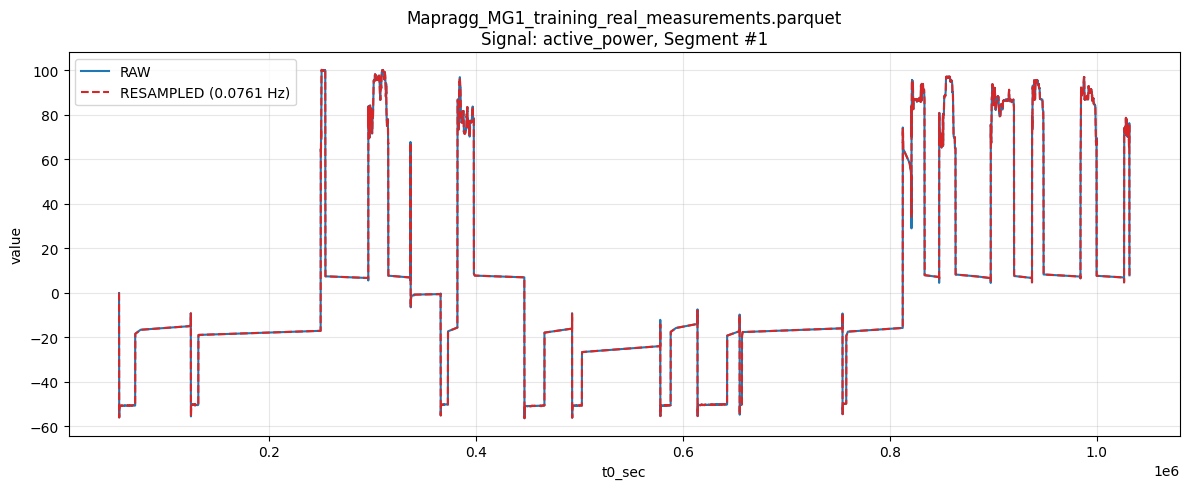

In [22]:
plot_raw_vs_resampled(
    "Mapragg_MG1_training_real_measurements.parquet",
    "active_power",
    1
)


In [23]:
# ============================================================
# FIXED-WINDOW SIGNAL VIEWER (SINGLE-PLOT FINAL VERSION)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import widgets, VBox, Output, interactive_output


def plot_resampled_segment_with_window(WINDOW_LENGTH=10.0):

    #------------------------------------------------------------
    # MAIN WIDGETS
    #------------------------------------------------------------
    file_dd = widgets.Dropdown(
        options=sorted(all_segments_resampled.keys()),
        description="Parquet",
        layout={"width": "400px"}
    )

    seg_slider = widgets.IntSlider(
        description="Segment",
        min=0, max=0, value=0, step=1,
        continuous_update=False,
        layout={"width": "400px"}
    )

    slider_box = VBox()
    plot_out = Output()

    # FLAG TO PREVENT DOUBLE PLOTTING
    initializing = {"active": True}

    #------------------------------------------------------------
    # VIEWER FUNCTION
    #------------------------------------------------------------
    def viewer(filename, seg_index, window_start):

        if initializing["active"]:
            return

        signals = [
            "active_power",
            "guide_vane_position",
            "water_pressure_downstream",
            "water_pressure_upstream",
            "ball_valve_closed",
            "ball_valve_open",
        ]

        units = {
            "active_power": "[W]",
            "guide_vane_position": "[%]",
            "water_pressure_downstream": "[bar]",
            "water_pressure_upstream": "[bar]",
            "ball_valve_closed": "[-]",
            "ball_valve_open": "[-]",
        }

        colors = [
            "tab:blue", "tab:orange", "tab:green",
            "tab:red", "tab:purple", "tab:brown"
        ]

        segdict = all_segments_resampled[filename]

        t0 = window_start
        t1 = window_start + WINDOW_LENGTH

        fig, axes = plt.subplots(
            len(signals), 1,
            figsize=(12, 2.6 * len(signals)),
            sharex=False           # <- IMPORTANT to let each subplot have ticks
        )

        for ax, sig, color in zip(axes, signals, colors):

            seg = segdict[sig][seg_index]
            mask = (seg["t0_sec"] >= t0) & (seg["t0_sec"] <= t1)
            seg_win = seg.loc[mask]

            ax.plot(seg_win["t0_sec"], seg_win["value"], color=color)
            ax.set_ylabel(f"{sig.replace('_',' ')} {units[sig]}", fontsize=9)
            ax.set_xlabel("time [s]", fontsize=9)
            ax.grid(True, alpha=0.3)

            # ---- NEW: explicit tick labels ----
            xticks = np.linspace(t0, t1, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels([f"{x:.0f}" for x in xticks], fontsize=8)

        fig.suptitle(
            f"{filename} – Segment {seg_index+1}",
            y=1.02
        )
        plt.tight_layout()
        plt.show()



    #------------------------------------------------------------
    # SEGMENT SLIDER UPDATE
    #------------------------------------------------------------
    def update_seg_slider(*args):
        fname = file_dd.value
        seg_slider.max = len(all_segments_resampled[fname]["active_power"]) - 1
        seg_slider.value = 0

    file_dd.observe(update_seg_slider, names="value")
    update_seg_slider()

    #------------------------------------------------------------
    # BUILD SLIDER
    #------------------------------------------------------------
    def build_slider(t_min, t_max):
        duration = t_max - t_min

        if duration <= WINDOW_LENGTH:
            return widgets.FloatSlider(
                description="Start time",
                min=t_min, max=t_min, value=t_min,
                continuous_update=False,
                layout={"width": "90%"}
            )

        return widgets.FloatSlider(
            description="Start time",
            min=t_min, max=t_max - WINDOW_LENGTH,
            value=t_min,
            step=WINDOW_LENGTH / 200,
            continuous_update=False,
            layout={"width": "90%"}
        )

    #------------------------------------------------------------
    # REBUILD SLIDER AND CONNECT VIEWER
    #------------------------------------------------------------
    def rebuild_slider(*args):
        fname = file_dd.value
        seg_idx = seg_slider.value
        seg = all_segments_resampled[fname]["active_power"][seg_idx]

        if len(seg) < 2:
            s = widgets.FloatSlider(description="Start time", min=0, max=0, value=0, disabled=True)
            slider_box.children = (s,)
            return

        t_min = float(seg["t0_sec"].min())
        t_max = float(seg["t0_sec"].max())

        if not np.isfinite(t_min) or not np.isfinite(t_max):
            s = widgets.FloatSlider(description="Start time", min=0, max=0, value=0, disabled=True)
            slider_box.children = (s,)
            return

        if t_max <= t_min:
            t_max = t_min + 1e-6

        # Build new slider
        new_slider = build_slider(t_min, t_max)

        # Connect viewer
        out = interactive_output(
            viewer,
            {
                "filename": file_dd,
                "seg_index": seg_slider,
                "window_start": new_slider
            }
        )

        plot_out.clear_output(wait=True)
        with plot_out:
            display(out)

        slider_box.children = (new_slider,)

    # Observers
    file_dd.observe(rebuild_slider, names="value")
    seg_slider.observe(rebuild_slider, names="value")

    # First run (no plot)
    rebuild_slider()
    initializing["active"] = False  # allow plotting now

    #------------------------------------------------------------
    display(VBox([file_dd, seg_slider, slider_box, plot_out]))


# RUN IT
plot_resampled_segment_with_window(WINDOW_LENGTH=10000.0)


# 7. Active power segragation into Turbine/Pump/Other


In [24]:
def extract_active_power(df):
    """Extract active power as a time series with datetime index."""
    ap = df[df["signal_name"] == "active_power"][["ts", "value"]].copy()
    if ap.empty:
        raise ValueError("No active_power signal found.")
    
    ap = ap.sort_values("ts").set_index("ts")

    # Ensure monotonic index
    ap = ap[~ap.index.duplicated(keep="first")]
    
    return ap["value"]


def detect_steady_states(
    P,
    roll_sec=60,            # rolling window (sec)
    std_thr=1.0,            # max allowed rolling std for steady state
    min_power=5.0,          # minimum |Power| to be considered "active"
    min_duration=30         # min length of a stable segment (sec)
):
    """
    Detect stable segments in active power signal.
    Returns: list of dicts with start, end, mean_power, classification
    """

    # Determine approximate sampling interval
    dt = P.index.to_series().diff().median().total_seconds()
    if pd.isna(dt) or dt <= 0:
        dt = 1.0

    win = max(1, int(round(roll_sec / dt)))

    # Rolling standard deviation for stability check
    P_std = P.rolling(win, center=True, min_periods=1).std()

    # Condition for steady: low std AND |P| > min_power
    steady_mask = (P_std <= std_thr) & (P.abs() >= min_power)

    # Create segments from steady_mask changes
    segments = []
    seg_id = (steady_mask != steady_mask.shift()).cumsum()

    for _, seg_idx in P.groupby(seg_id):
        idx = seg_idx.index

        # Check steady or not
        is_steady = steady_mask.loc[idx].iloc[0]

        start = idx.min()
        end   = idx.max()
        duration = (end - start).total_seconds()

        if not is_steady:
            continue  # skip non-steady intervals

        if duration < min_duration:
            continue  # too short → ignore

        P_mean = P.loc[idx].mean()

        # classify
        if P_mean > min_power:
            mode = "turbine"
        elif P_mean < -min_power:
            mode = "pump"
        else:
            mode = "other"

        segments.append({
            "start": start,
            "end": end,
            "duration_sec": duration,
            "mean_power": P_mean,
            "mode": mode
        })

    return segments


def classify_modes_in_df(df, **kwargs):
    """
    Adds 'mode' column to full dataframe:
    - turbine
    - pump
    - other
    - transient (everything outside steady segments)
    """
    P = extract_active_power(df)
    segments = detect_steady_states(P, **kwargs)

    # default: everything transient
    df = df.sort_values("ts").copy()
    df["mode"] = "transient"

    # fill steady segments with labels
    for seg in segments:
        mask = (df["ts"] >= seg["start"]) & (df["ts"] <= seg["end"])
        df.loc[mask, "mode"] = seg["mode"]

    return df, segments


In [26]:
df = pd.read_parquet("data/Mapragg_MG1_training_real_measurements.parquet")
df["ts"] = pd.to_datetime(df["ts"])

df = df.merge(df_mapping, on="signal_id", how="left")

df_modes, steady_segments = classify_modes_in_df(
    df,
    roll_sec=60,
    std_thr=1.0,
    min_power=5.0,
    min_duration=30
)

print("Detected steady segments:")
for seg in steady_segments:
    print(seg)


Detected steady segments:
{'start': Timestamp('2020-06-03 08:52:15.904000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 09:46:40.630000+0000', tz='UTC'), 'duration_sec': 3264.726, 'mean_power': 76.7876388107521, 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 09:46:48.091000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 10:00:16.813000+0000', tz='UTC'), 'duration_sec': 808.722, 'mean_power': 78.349120367141, 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 10:00:31.019000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 10:01:15.850000+0000', tz='UTC'), 'duration_sec': 44.831, 'mean_power': 71.37403945922851, 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 16:54:35.840000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 17:30:22.409000+0000', tz='UTC'), 'duration_sec': 2146.569, 'mean_power': 69.78574716009895, 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 17:30:51.763000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 18:00:21.477000+0000', tz='UTC'), 'duration_sec': 1769.71

In [ ]:
SIGNALS_FOR_CORR = [
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
    "ball_valve_closed", 
    "ball_valve_open",
]

def fix_sarelli_power_sign(df):
    """
    Invert active_power for Sarelli only.
    Applies AFTER merging with df_mapping.
    """

    mask = (df["stage"] == "Sarelli") & (df["signal_name"] == "active_power")
    df.loc[mask, "value"] *= -1
    return df


# ============================================================
# 1. UTILITY: Extract active power
# ============================================================
def extract_active_power(df):
    ap = df[df["signal_name"] == "active_power"][["ts", "value"]].copy()
    if ap.empty:
        raise ValueError("No active_power signal found in df.")

    ap = ap.sort_values("ts").set_index("ts")
    ap = ap[~ap.index.duplicated()]
    return ap["value"]


# ============================================================
# 2. Detect steady-state windows based on active power stability
# ============================================================
def detect_steady_states(
    P,
    roll_sec=60,         # rolling window for std
    std_thr=1.0,         # max std allowed for steady-state
    min_power=5.0,       # threshold for turbine/pump differentiation
    min_duration=30      # segment min duration (seconds)
):
    dt = P.index.to_series().diff().median().total_seconds()
    if pd.isna(dt) or dt <= 0:
        dt = 1.0

    win = max(1, int(round(roll_sec / dt)))

    P_std = P.rolling(win, center=True, min_periods=1).std()

    steady_mask = (P_std <= std_thr) & (P.abs() >= min_power)

    segments = []
    seg_id = (steady_mask != steady_mask.shift()).cumsum()

    for _, seg in P.groupby(seg_id):
        idx = seg.index
        is_steady = steady_mask.loc[idx].iloc[0]

        if not is_steady:
            continue

        start = idx.min()
        end = idx.max()
        duration = (end - start).total_seconds()
        if duration < min_duration:
            continue

        P_mean = P.loc[idx].mean()

        # classification
        if P_mean >= min_power:
            mode = "turbine"
        elif P_mean <= -min_power:
            mode = "pump"
        else:
            mode = "other"

        segments.append({
            "start": start,
            "end": end,
            "duration": duration,
            "mean_power": P_mean,
            "mode": mode
        })

    return segments


# ============================================================
# 3. Add "mode" column to entire dataframe
# ============================================================
def classify_modes_in_df(df, **kwargs):
    df = df.sort_values("ts").copy()
    df["mode"] = "transient"

    P = extract_active_power(df)
    steady_segments = detect_steady_states(P, **kwargs)

    for seg in steady_segments:
        mask = (df["ts"] >= seg["start"]) & (df["ts"] <= seg["end"])
        df.loc[mask, "mode"] = seg["mode"]

    return df, steady_segments


# ============================================================
# 4. Split df into mode-homogeneous segments
# ============================================================
def split_into_mode_segments(df_modes):
    df_modes = df_modes.sort_values("ts").copy()
    seg_id = (df_modes["mode"] != df_modes["mode"].shift()).cumsum()

    mode_segments = []

    for _, segdf in df_modes.groupby(seg_id):
        mode = segdf["mode"].iloc[0]
        if mode == "transient":
            continue

        mode_segments.append({
            "mode": mode,
            "df": segdf.copy(),
            "start": segdf["ts"].min(),
            "end": segdf["ts"].max()
        })

    return mode_segments


# ============================================================
# 5. Convert segment to wide format
# ============================================================
def make_wide(seg_df, signals=SIGNALS_FOR_CORR):
    """
    Convert long-format segment into wide format for selected signals.
    index = ts, columns = signal_name, values = value
    """
    seg_df = seg_df[seg_df["signal_name"].isin(signals)]
    if seg_df.empty:
        return None

    pivot = seg_df.pivot_table(
        index="ts",
        columns="signal_name",
        values="value",
        aggfunc="mean",
    ).sort_index()

    # forward/backward fill in time
    pivot = pivot.ffill().bfill()

    # drop columns with no variance -> corr would be NaN
    var = pivot.var()
    pivot = pivot.loc[:, var > 0]

    if pivot.shape[1] < 2:
        return None  # not enough varying signals to correlate

    return pivot


# ============================================================
# FIXED segment_correlation()  — only one correct definition
# ============================================================

def segment_correlation(seg_df, signals=SIGNALS_FOR_CORR):
    """
    Compute full correlation matrix for the given segment.
    Uses make_wide() to ensure consistent signal coverage.
    Guarantees full matrix and diagonal=1.
    """
    wide = make_wide(seg_df, signals=signals)
    if wide is None:
        return None

    # Compute correlation
    C = wide.corr()

    # Reindex to ensure all required signals appear
    C = C.reindex(index=signals, columns=signals)

    # Replace diagonal with 1.0
    np.fill_diagonal(C.values, 1.0)

    return C



# ============================================================
# 7. Aggregate correlations per mode
# ============================================================
def aggregate_corrs(corr_list, signals=SIGNALS_FOR_CORR):
    """
    Aggregate a list of correlation DataFrames using NaN-aware mean.
    Returns a DataFrame with index/columns = signals.
    """
    if not corr_list:
        return None

    mats = []
    for C in corr_list:
        if C is None:
            continue
        # reindex to full signal set; missing entries -> NaN
        C2 = C.reindex(index=signals, columns=signals)
        mats.append(C2.to_numpy(dtype=float))

    if not mats:
        return None

    arr = np.stack(mats, axis=0)           # shape: (n_segments, n_signals, n_signals)
    m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging

    return pd.DataFrame(m, index=signals, columns=signals)



# ============================================================
# 8. FULL PARQUET PIPELINE
# ============================================================
def process_parquet(path, df_mapping,
                    roll_sec=60, std_thr=1.0,
                    min_power=5.0, min_duration=30):

    print(f"\n=== Processing {path} ===")

    df = pd.read_parquet(path)
    df["ts"] = pd.to_datetime(df["ts"], utc=False)

    # ----------------------------------------
    # Merge FIRST so stage and signal_name exist
    # ----------------------------------------
    df = df.merge(df_mapping, on="signal_id", how="left")

    # ----------------------------------------
    # FIX SARELLI SIGN BEFORE ANY PROCESSING
    # ----------------------------------------
    df = fix_sarelli_power_sign(df)

    # ----------------------------------------
    # Mode classification & segment extraction
    # ----------------------------------------
    df_modes, steady_segments = classify_modes_in_df(
        df,
        roll_sec=roll_sec,
        std_thr=std_thr,
        min_power=min_power,
        min_duration=min_duration
    )

    print(f"Detected {len(steady_segments)} steady segments.")

    # Segment per mode (steady only)
    mode_segments = split_into_mode_segments(df_modes)

    # ----------------------------------------
    # Correlation tables for steady modes
    # ----------------------------------------
    turbine_corrs = []
    pump_corrs = []
    other_corrs = []

    for seg in mode_segments:
        C = segment_correlation(seg["df"], signals=SIGNALS_FOR_CORR)
        if C is None:
            continue

        if seg["mode"] == "turbine":
            turbine_corrs.append(C)
        elif seg["mode"] == "pump":
            pump_corrs.append(C)
        else:
            other_corrs.append(C)

    agg_turbine = aggregate_corrs(turbine_corrs, signals=SIGNALS_FOR_CORR)
    agg_pump    = aggregate_corrs(pump_corrs,    signals=SIGNALS_FOR_CORR)
    agg_other   = aggregate_corrs(other_corrs,   signals=SIGNALS_FOR_CORR)

    # ----------------------------------------
    # NEW: Correlation for all remaining data (not turbine, not pump)
    #      This includes transient + any 'other' or additional modes.
    # ----------------------------------------
    mask_rest = ~df_modes["mode"].isin(["turbine", "pump"])
    if mask_rest.any():
        rest_df = df_modes[mask_rest]
        corr_rest = segment_correlation(rest_df, signals=SIGNALS_FOR_CORR)
    else:
        corr_rest = None

    return {
        "file": path,
        "df_modes": df_modes,
        "segments": mode_segments,
        "corr_turbine": agg_turbine,
        "corr_pump": agg_pump,
        "corr_other": agg_other,
        "corr_rest": corr_rest,   # <- NEW
    }


In [27]:
def plot_mode_corr_heatmaps(result_dict):
    file = result_dict["file"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # TURBINE
    if result_dict["corr_turbine"] is not None:
        sns.heatmap(result_dict["corr_turbine"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[0])
        axes[0].set_title(f"{file}\nTURBINE correlation")
    else:
        axes[0].set_title("No turbine steady-state segments")

    # PUMP
    if result_dict["corr_pump"] is not None:
        sns.heatmap(result_dict["corr_pump"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[1])
        axes[1].set_title(f"{file}\nPUMP correlation")
    else:
        axes[1].set_title("No pump steady-state segments")

    # REMAINING (NOT TURBINE / NOT PUMP)
    if result_dict.get("corr_rest") is not None:
        sns.heatmap(result_dict["corr_rest"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[2])
        axes[2].set_title(f"{file}\n TRANSIENT STATE correlation")
    else:
        axes[2].set_title("No remaining data for correlation")

    plt.tight_layout()
    plt.show()



=== Processing Mapragg_MG1_testing_real_measurements.parquet ===
Detected 701 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


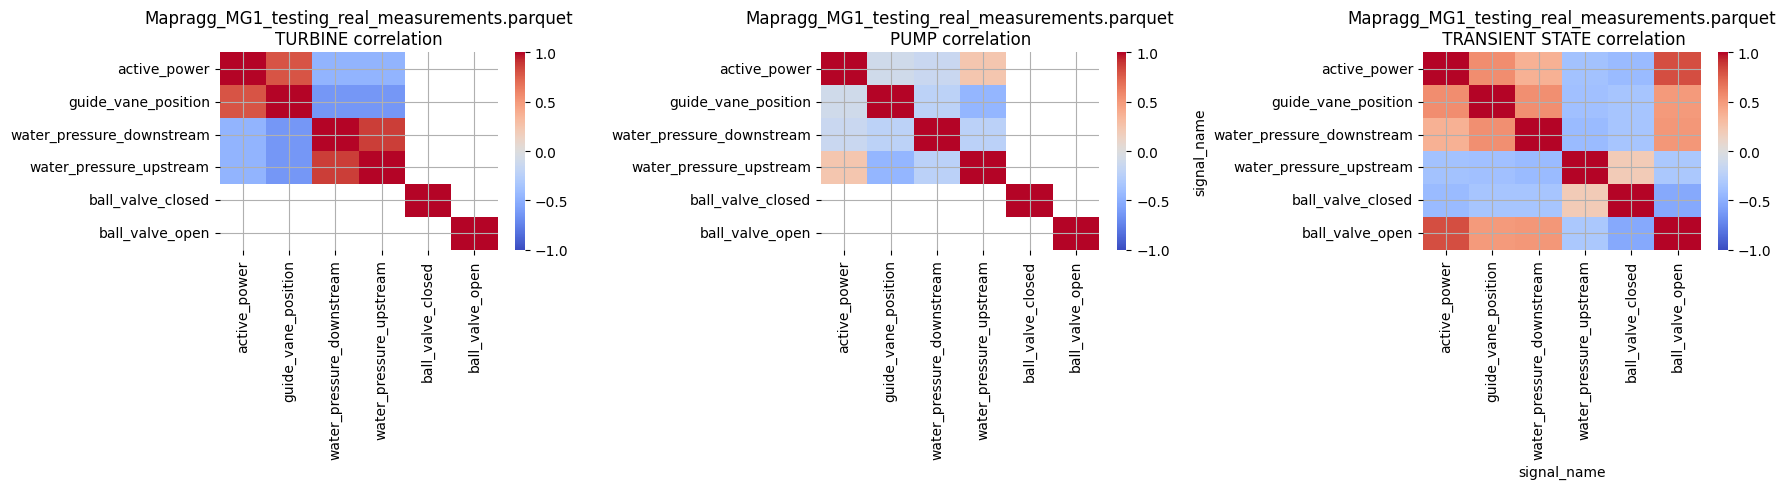


=== Processing Mapragg_MG1_training_real_measurements.parquet ===
Detected 2552 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


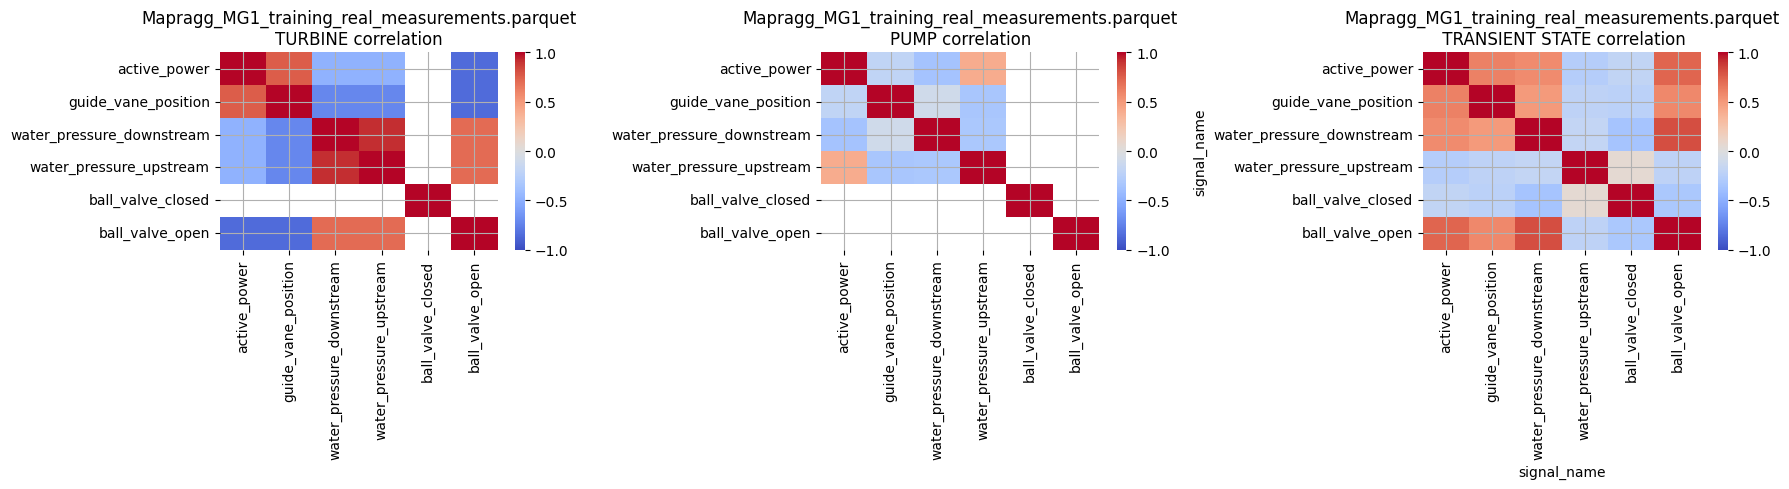


=== Processing Mapragg_MG2_testing_real_measurements.parquet ===
Detected 471 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


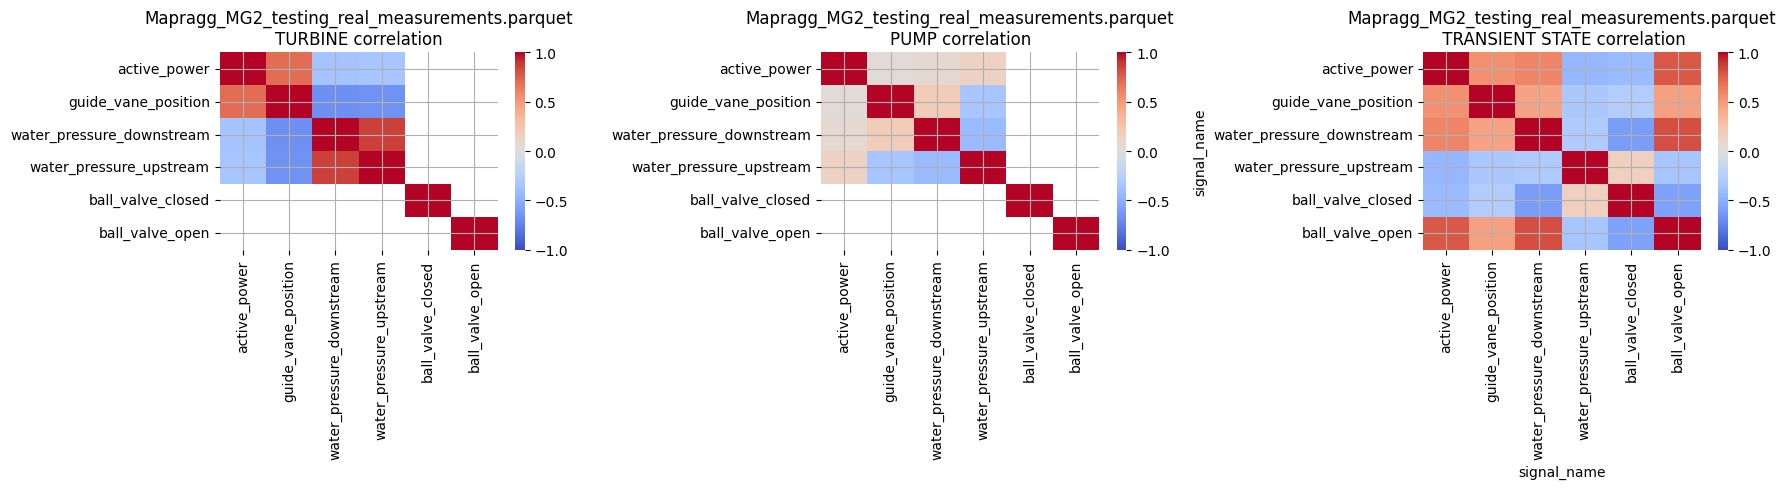


=== Processing Mapragg_MG2_training_real_measurements.parquet ===
Detected 5484 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


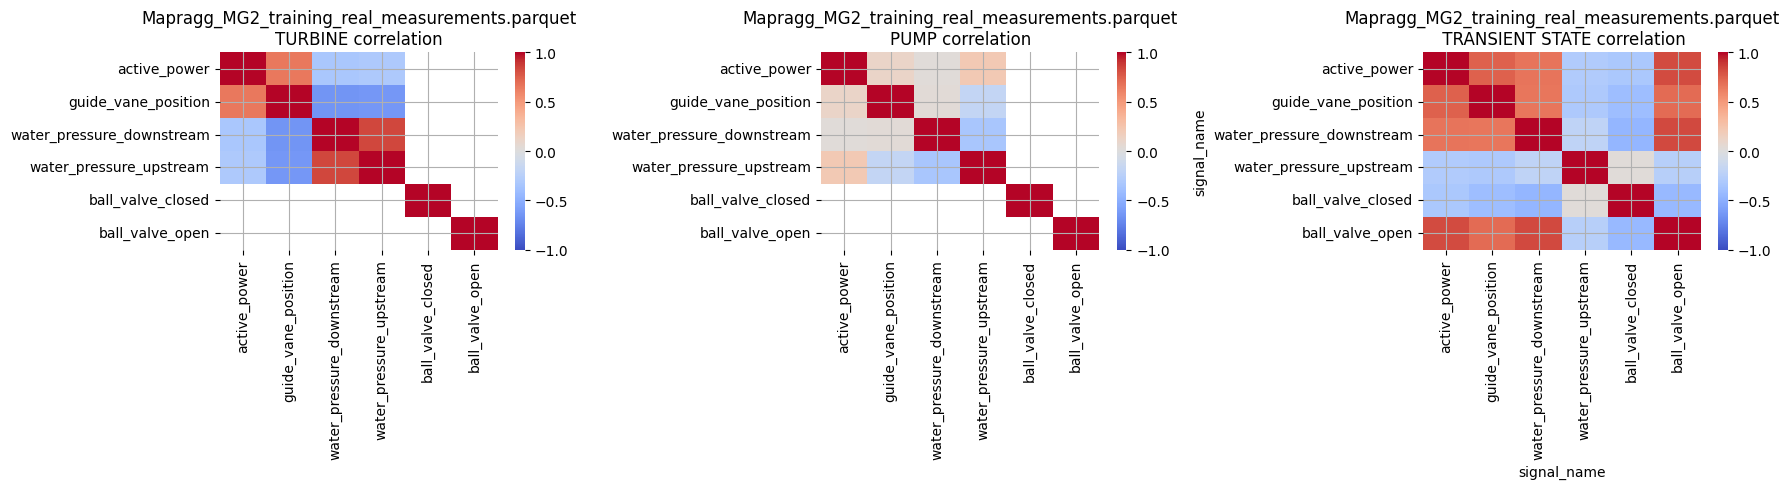


=== Processing Mapragg_MG3_testing_real_measurements.parquet ===
Detected 673 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


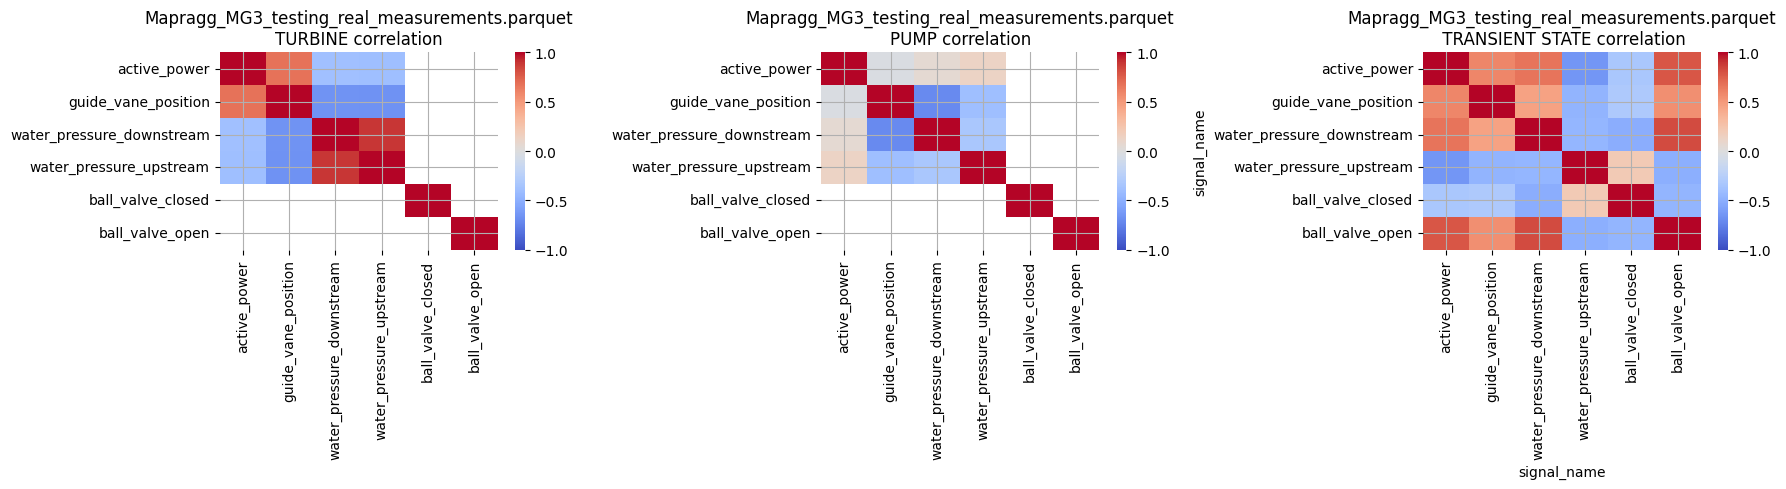


=== Processing Mapragg_MG3_training_real_measurements.parquet ===
Detected 2763 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


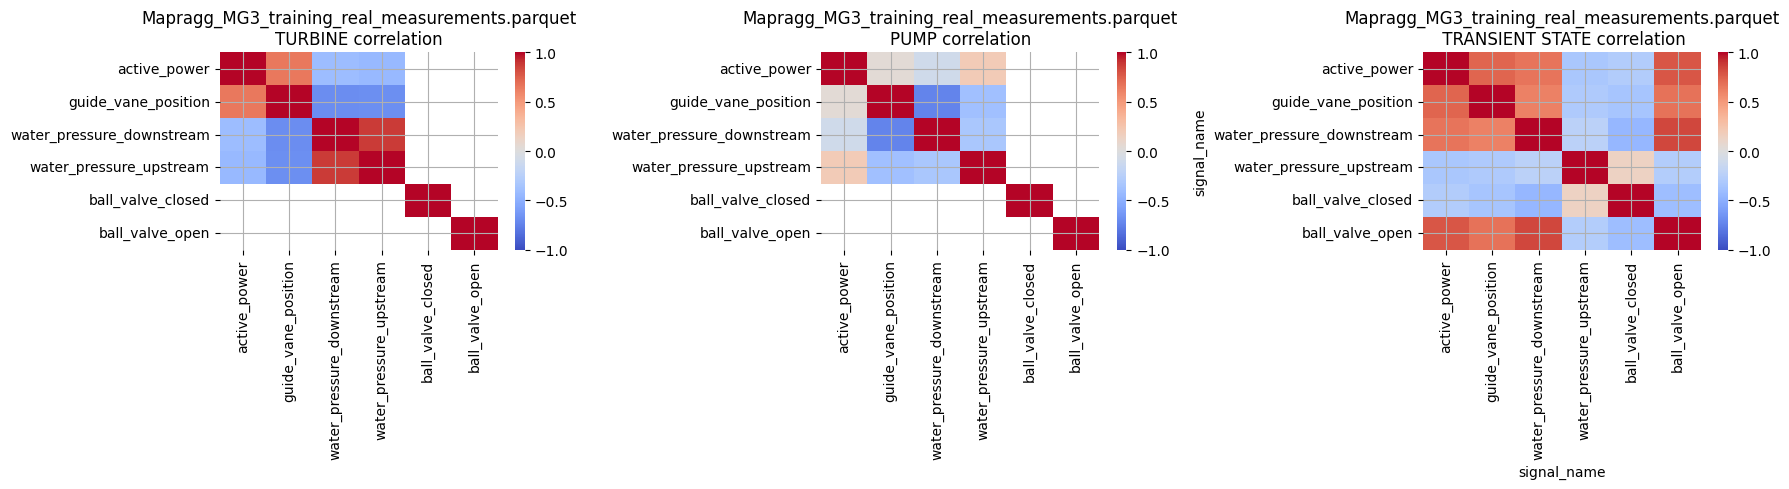


=== Processing Sarelli_MG1_testing_real_measurements.parquet ===
Detected 132 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


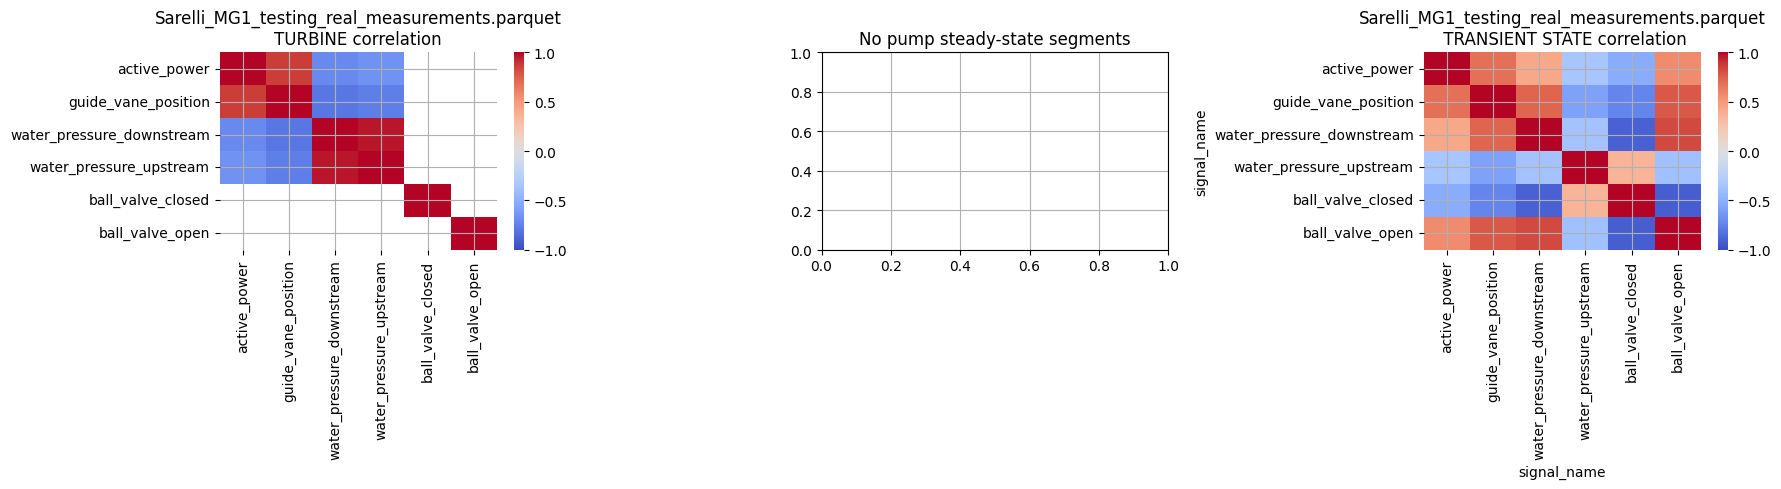


=== Processing Sarelli_MG1_training_real_measurements.parquet ===
Detected 422 steady segments.


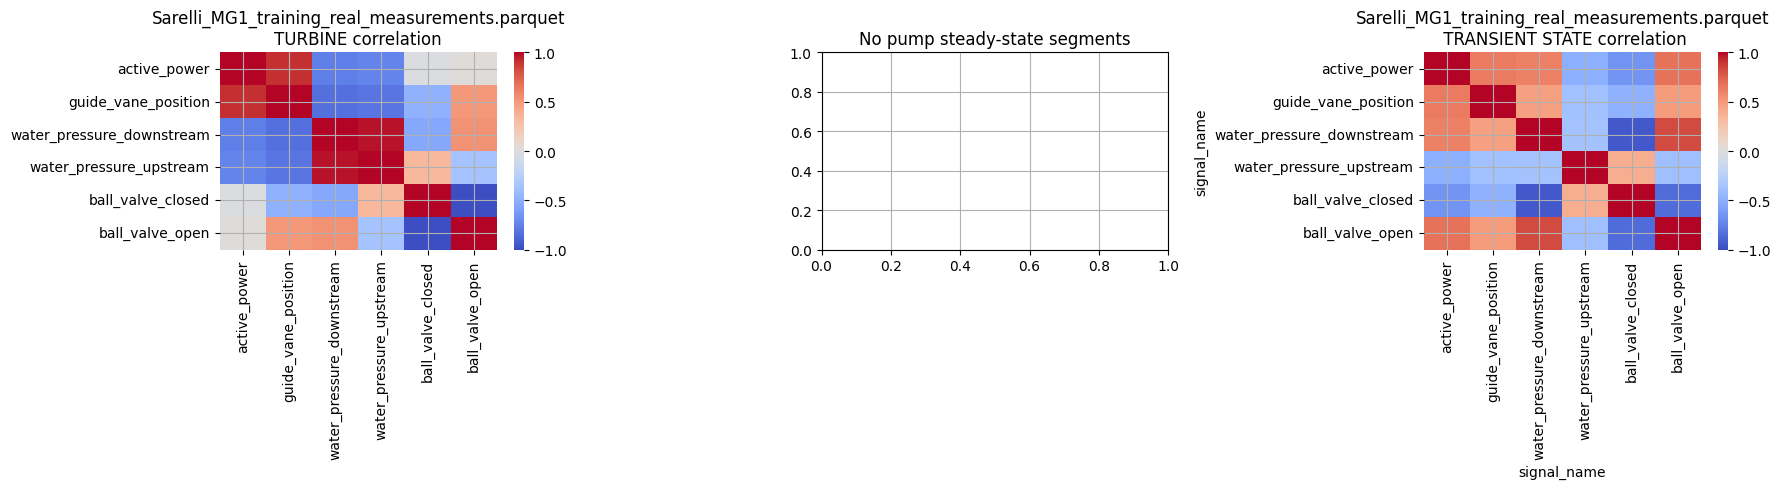


=== Processing Sarelli_MG2_testing_real_measurements.parquet ===
Detected 203 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


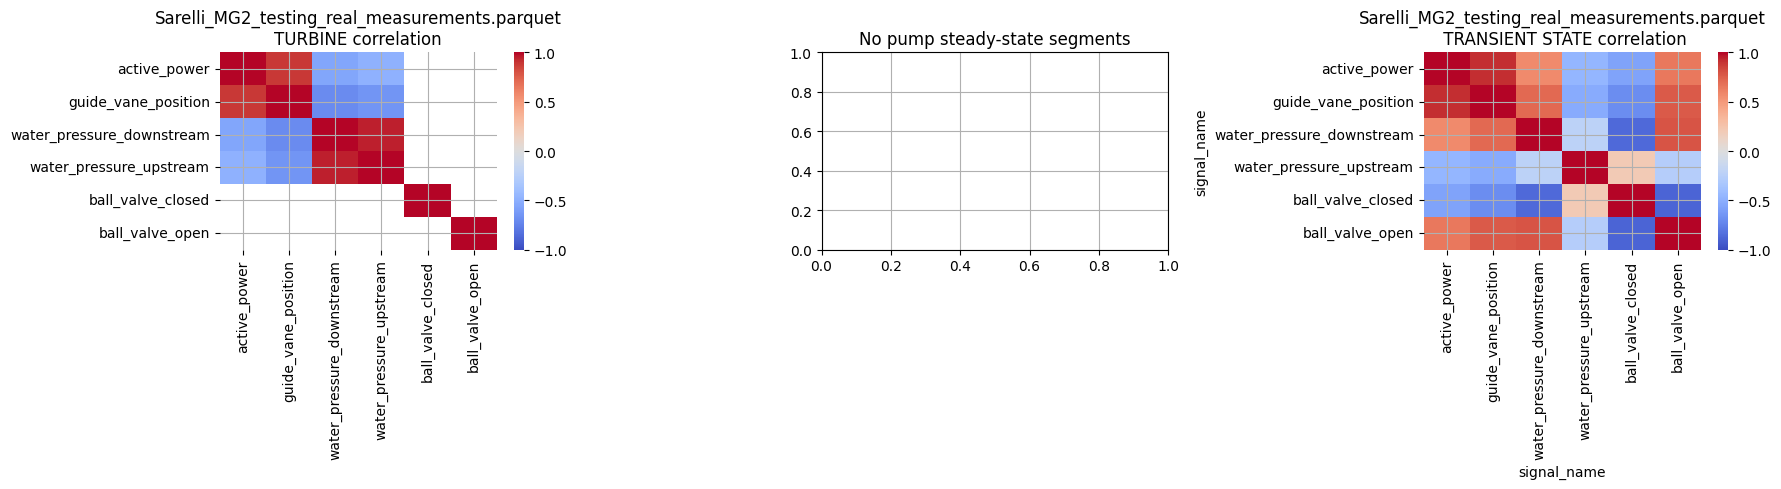


=== Processing Sarelli_MG2_training_real_measurements.parquet ===
Detected 934 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


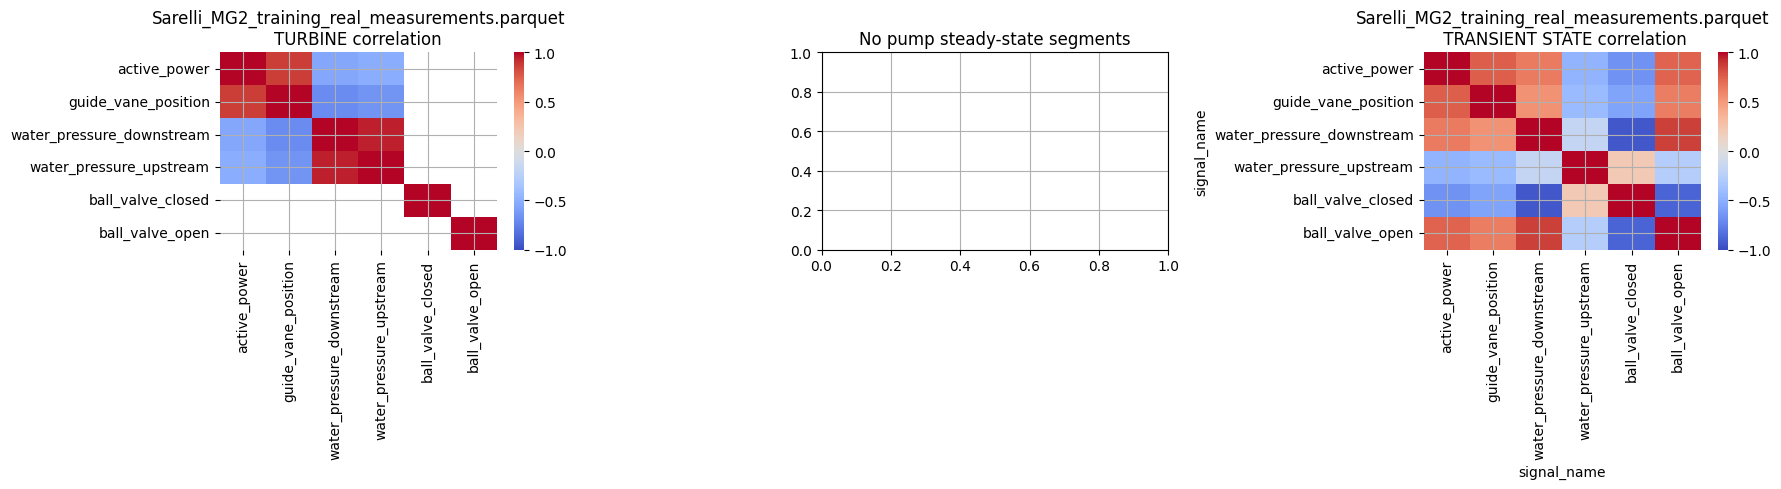

In [28]:
results = {}

for path in parquet_files:
    res = process_parquet(path, df_mapping)
    results[path] = res
    plot_mode_corr_heatmaps(res)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The signals you want to analyze:
SIGNALS_FOR_DIST = [
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
    "ball_valve_closed",
    "ball_valve_open",
]

def extract_resampled_distributions(all_segments_resampled):
    """
    Returns a nested structure:
    distributions[station][dataset_type][signal] = describe()
    """

    distributions = {"Mapragg": {}, "Sarelli": {}}

    for parquet_name, entry in all_segments_resampled.items():
        
        station = entry["stage"]        # "Mapragg" or "Sarelli"
        dtype   = entry["dataset_type"] # "training" or "testing"

        if dtype not in distributions[station]:
            distributions[station][dtype] = {}

        # Loop over signals
        for sig in SIGNALS_FOR_DIST:
            seglist = entry[sig] if sig in entry else None
            if seglist is None:
                continue

            # Combine all resampled segments for this parquet + signal
            df_combined = pd.concat(seglist, ignore_index=True)

            if sig not in distributions[station][dtype]:
                distributions[station][dtype][sig] = [df_combined["value"]]
            else:
                distributions[station][dtype][sig].append(df_combined["value"])

    # Convert lists of arrays → descriptive statistics
    for station in distributions:
        for dtype in distributions[station]:
            for sig in distributions[station][dtype]:
                values = pd.concat(distributions[station][dtype][sig], ignore_index=True)
                distributions[station][dtype][sig] = values.describe(percentiles=[0.05, 0.5, 0.95])

    return distributions


# ---- RUN IT ----
resampled_dists = extract_resampled_distributions(all_segments_resampled)

print("=== Mapragg — Training ===")
print(resampled_dists["Mapragg"]["training"])

print("\n=== Mapragg — Testing ===")
print(resampled_dists["Mapragg"]["testing"])

print("\n=== Sarelli — Training ===")
print(resampled_dists["Sarelli"]["training"])

print("\n=== Sarelli — Testing ===")
print(resampled_dists["Sarelli"]["testing"])


=== Mapragg — Training ===
{'active_power': count    6.037082e+06
mean     1.101003e+00
std      4.178224e+01
min     -6.070358e+01
5%      -5.155593e+01
50%     -7.296253e-01
95%      9.217306e+01
max      1.173420e+02
Name: value, dtype: float64, 'guide_vane_position': count    6.372748e+06
mean     2.717989e+01
std      3.963860e+01
min      0.000000e+00
5%       7.276895e-02
50%      6.666378e-01
95%      9.984548e+01
max      9.999726e+01
Name: value, dtype: float64, 'water_pressure_downstream': count    6.374345e+06
mean     6.602784e+00
std      1.596515e+01
min     -1.337714e+00
5%      -1.162263e+00
50%      1.433193e-01
95%      4.549170e+01
max      5.006855e+01
Name: value, dtype: float64, 'water_pressure_upstream': count    6.375086e+06
mean     4.669184e+01
std      1.966175e+00
min      3.643536e-01
5%       4.303295e+01
50%      4.731643e+01
95%      4.880642e+01
max      5.038498e+01
Name: value, dtype: float64, 'ball_valve_closed': count    6.047872e+06
mean     8.370

In [ ]:
def plot_resampled_histograms(all_segments_resampled, bins=80):

    # Mapping from signal_name → nice title + x-axis label
    LABELS = {
        "active_power": ("Active power", "Active power [MW]"),
        "guide_vane_position": ("Guide vane position", "Guide vane position [%]"),
        "water_pressure_downstream": ("Downward water pressure", "Downward water pressure [bar]"),
        "water_pressure_upstream": ("Upward water pressure", "Upward water pressure [bar]"),
        "ball_valve_closed": ("Ball valve closed", "Ball valve closed [-]"),
        "ball_valve_open": ("Ball valve open", "Ball valve open [-]"),
    }

    colors = {"training": "steelblue", "testing": "firebrick"}

    for station in ["Mapragg", "Sarelli"]:

        # Collect data grouped by dataset type
        grouped = {"training": {}, "testing": {}}

        for parquet_name, entry in all_segments_resampled.items():
            if entry["stage"] != station:
                continue

            dtype = entry["dataset_type"]

            # gather per-signal resampled values
            for sig in SIGNALS_FOR_DIST:
                seglist = entry.get(sig, [])
                if not seglist:
                    continue
                df_sig = pd.concat(seglist, ignore_index=True)

                if sig not in grouped[dtype]:
                    grouped[dtype][sig] = [df_sig["value"]]
                else:
                    grouped[dtype][sig].append(df_sig["value"])

        # --- Create 3×2 grid ---
        fig, axes = plt.subplots(3, 2, figsize=(14, 12))
        fig.suptitle(f"{station} — Resampled Signal Distributions", fontsize=18)

        axes = axes.flatten()

        for ax, sig in zip(axes, SIGNALS_FOR_DIST):

            # Plot training/testing histograms
            for dtype in ["training", "testing"]:
                if sig not in grouped[dtype]:
                    continue

                vals = pd.concat(grouped[dtype][sig], ignore_index=True)

                ax.hist(vals, bins=bins, alpha=0.6,
                        color=colors[dtype], label=dtype)

            title, xlabel = LABELS[sig]
            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Count")
            ax.legend()

        # Clear any empty unused subplots (if any)
        for ax in axes[len(SIGNALS_FOR_DIST):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()


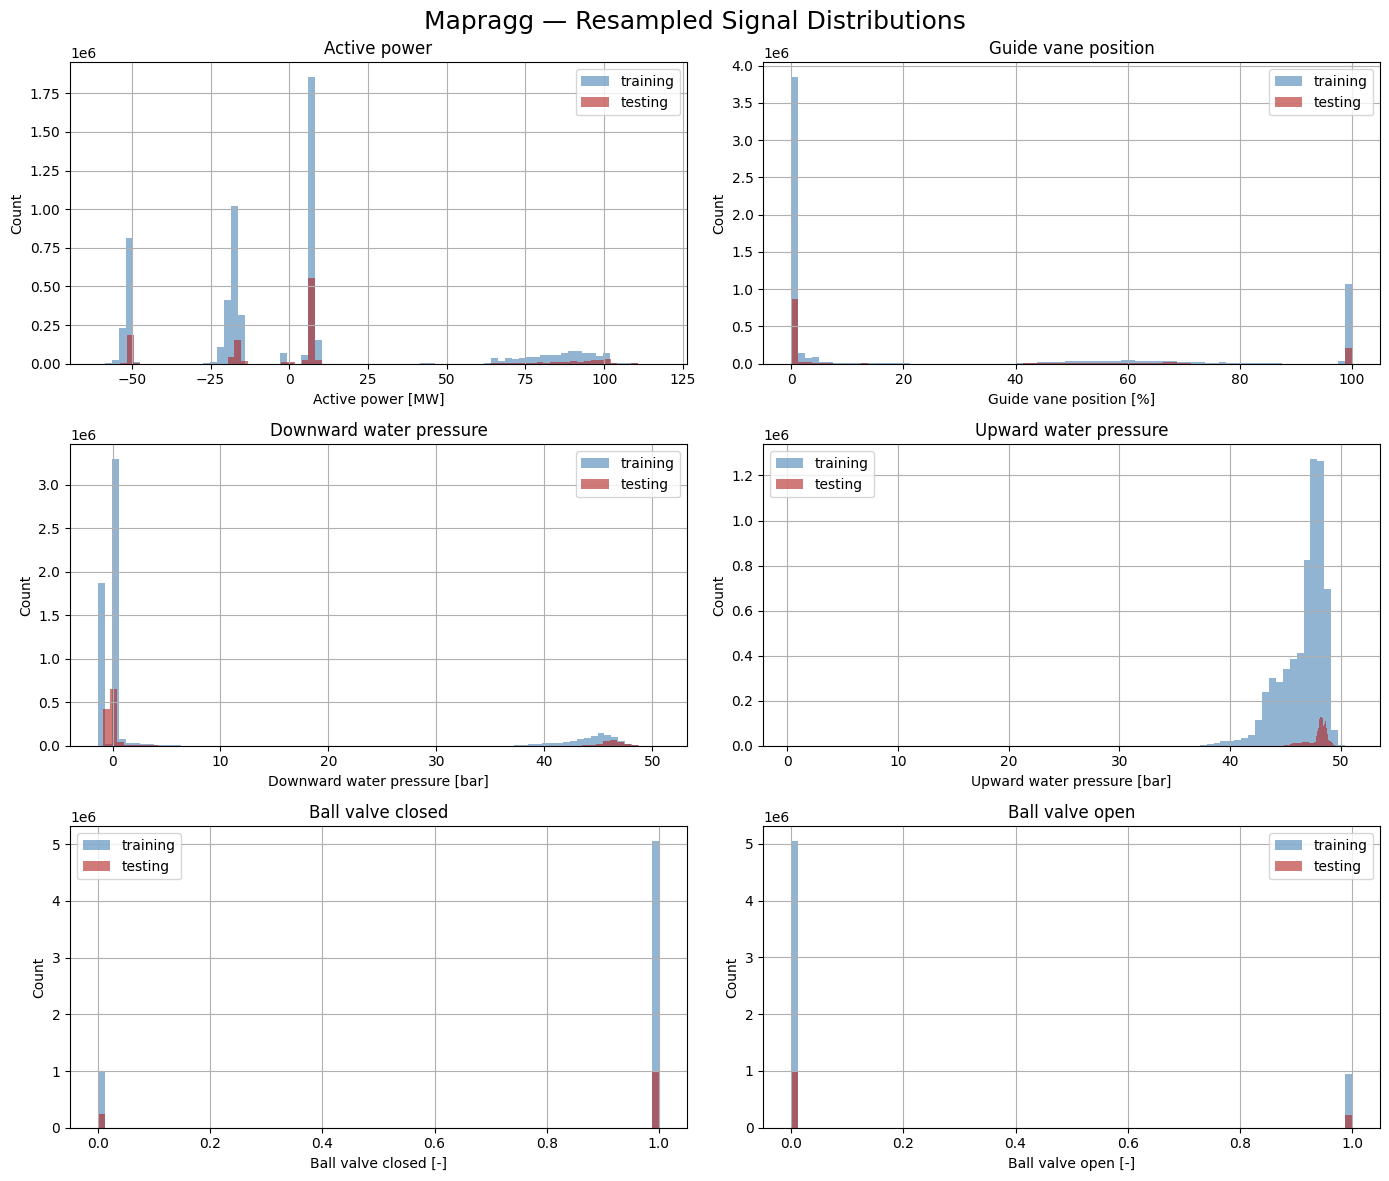

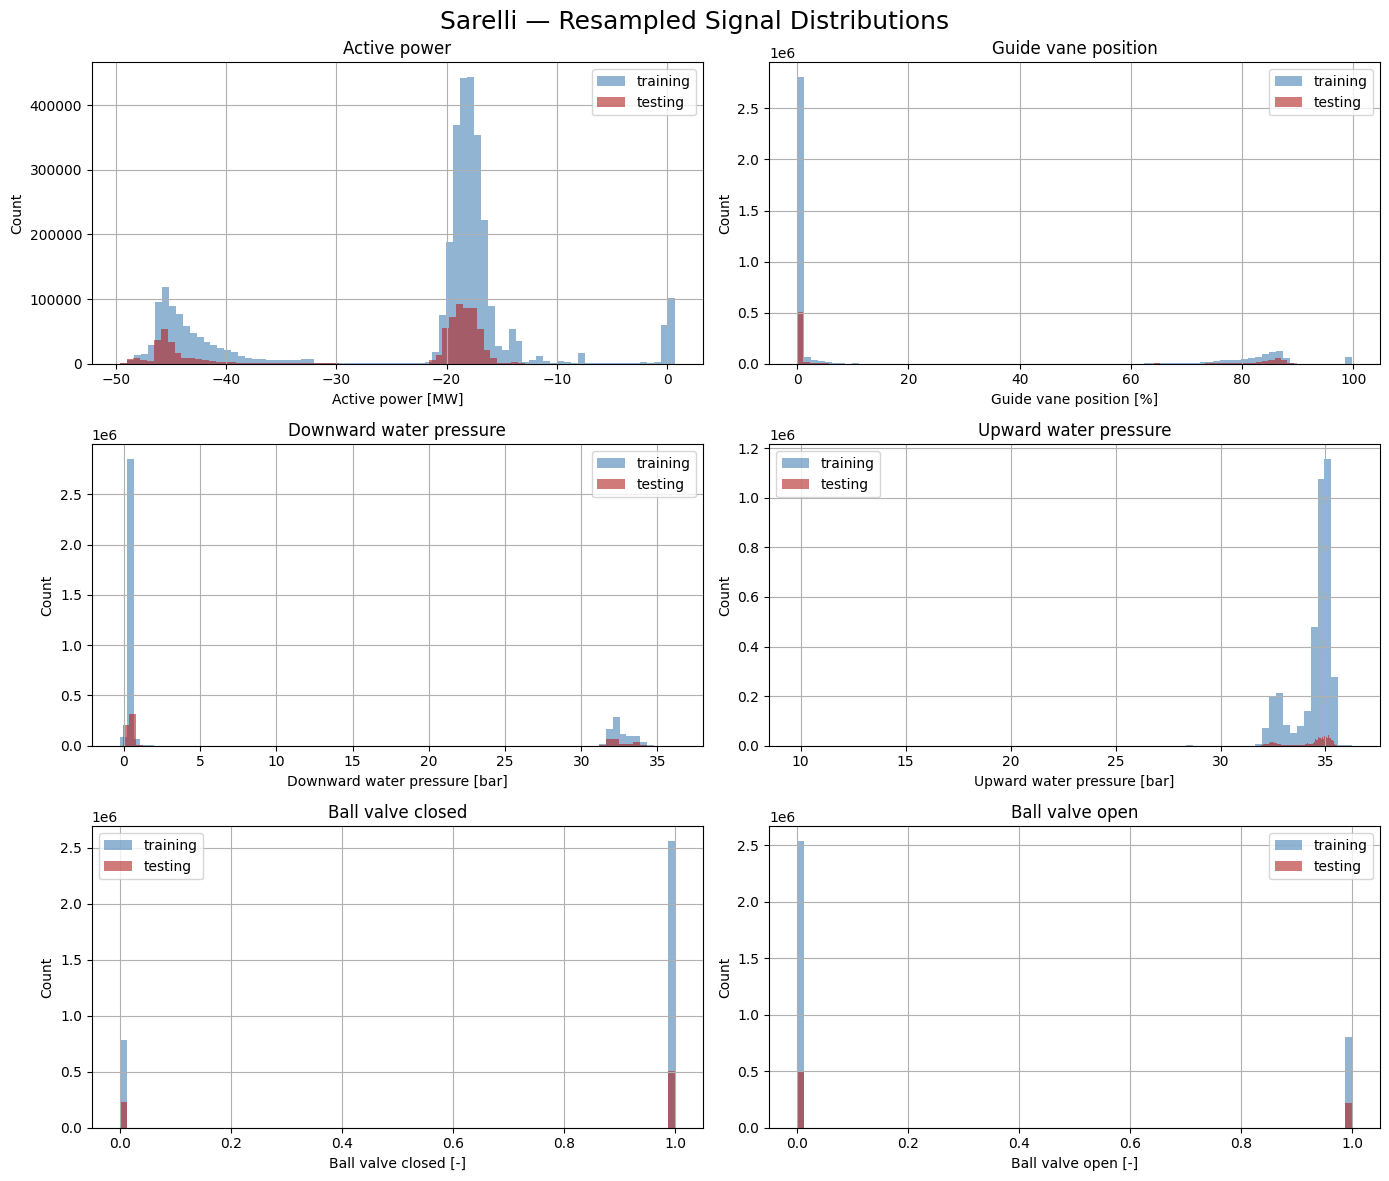

In [ ]:
plot_resampled_histograms(all_segments_resampled)


# 8. Segmentation into transition sets
## 8.1. Visualize the transitions


In [3]:
# Import all the data
parquet_files = sorted(
    [os.path.join('data', f) for f in os.listdir('data')
     if f.endswith('.parquet') and 'real_measurements' in f]
)


print('Found parquet files:')
for f in parquet_files:
    print('  -', f)


Found parquet files:
  - data/Mapragg_MG1_testing_real_measurements.parquet
  - data/Mapragg_MG1_training_real_measurements.parquet
  - data/Mapragg_MG2_testing_real_measurements.parquet
  - data/Mapragg_MG2_training_real_measurements.parquet
  - data/Mapragg_MG3_testing_real_measurements.parquet
  - data/Mapragg_MG3_training_real_measurements.parquet
  - data/Sarelli_MG1_testing_real_measurements.parquet
  - data/Sarelli_MG1_training_real_measurements.parquet
  - data/Sarelli_MG2_testing_real_measurements.parquet
  - data/Sarelli_MG2_training_real_measurements.parquet


In [29]:
# Process all parquet files using classify_modes_in_df

# Dictionary to store results for each asset
modes_by_asset = {}

print("Processing all parquet files with classify_modes_in_df...")
print("=" * 80)

for parquet_file in parquet_files:
    print(f"\nProcessing: {os.path.basename(parquet_file)}")
    
    # Load and prepare data
    df = pd.read_parquet(parquet_file)
    df["ts"] = pd.to_datetime(df["ts"])
    
    # Merge with mapping
    df = df.merge(df_mapping, on="signal_id", how="left")
    
    # Fix Sarelli power sign if needed
    if 'fix_sarelli_power_sign' in globals():
        df = fix_sarelli_power_sign(df)
    
    # Classify modes using steady state functions
    df_modes, steady_segments = classify_modes_in_df(
        df,
        roll_sec=60,
        std_thr=1.0,
        min_power=5.0,
        min_duration=30
    )
    
    # Store results
    asset_name = os.path.basename(parquet_file).replace('.parquet', '')
    modes_by_asset[asset_name] = {
        "file": parquet_file,
        "df_modes": df_modes,
        "steady_segments": steady_segments,
        "n_steady_segments": len(steady_segments),
        "metadata": {
            "stage": df_modes["stage"].iloc[0] if "stage" in df_modes.columns else "unknown",
            "machine_group": df_modes["machine_group"].iloc[0] if "machine_group" in df_modes.columns else "unknown",
        }
    }
    
    print(f"  Detected {len(steady_segments)} steady segments")

print("\n" + "=" * 80)
print(f"Summary: Processed {len(modes_by_asset)} assets")
print(f"Total steady segments across all assets: {sum(v['n_steady_segments'] for v in modes_by_asset.values())}")


Processing all parquet files with classify_modes_in_df...

Processing: Mapragg_MG1_testing_real_measurements.parquet
  Detected 701 steady segments

Processing: Mapragg_MG1_training_real_measurements.parquet
  Detected 2552 steady segments

Processing: Mapragg_MG2_testing_real_measurements.parquet
  Detected 471 steady segments

Processing: Mapragg_MG2_training_real_measurements.parquet
  Detected 5484 steady segments

Processing: Mapragg_MG3_testing_real_measurements.parquet
  Detected 673 steady segments

Processing: Mapragg_MG3_training_real_measurements.parquet
  Detected 2763 steady segments

Processing: Sarelli_MG1_testing_real_measurements.parquet
  Detected 132 steady segments

Processing: Sarelli_MG1_training_real_measurements.parquet
  Detected 422 steady segments

Processing: Sarelli_MG2_testing_real_measurements.parquet
  Detected 203 steady segments

Processing: Sarelli_MG2_training_real_measurements.parquet
  Detected 934 steady segments

Summary: Processed 10 assets
Tota

In [33]:

import os
import pickle

# Create output folder if it doesn't exist
output_folder = 'data_transitions'
os.makedirs(output_folder, exist_ok=True)

# Store modes_by_asset as a pickle file
with open(os.path.join(output_folder, 'modes_by_asset.pkl'), 'wb') as f:
    pickle.dump(modes_by_asset, f)

print(f"modes_by_asset saved to {os.path.join(output_folder, 'modes_by_asset.pkl')}")


modes_by_asset saved to data_transitions/modes_by_asset.pkl


In [30]:

# Interactive visualization of transitions (works directly with modes_by_asset from cell 38)

def extract_transitions_for_asset(asset_name):
    """Extract transition segments for a given asset from modes_by_asset"""
    if asset_name not in modes_by_asset:
        return []
    
    asset_data = modes_by_asset[asset_name]
    df_modes = asset_data["df_modes"]
    steady_segments = asset_data["steady_segments"]
    
    # Transitions are everything where mode == "transient"
    df_transitions = df_modes[df_modes["mode"] == "transient"].copy()
    
    if df_transitions.empty:
        return []
    
    # Mark steady state periods
    df_modes_copy = df_modes.sort_values("ts").copy()
    df_modes_copy["is_steady"] = False
    for seg in steady_segments:
        mask = (df_modes_copy["ts"] >= seg["start"]) & (df_modes_copy["ts"] <= seg["end"])
        df_modes_copy.loc[mask, "is_steady"] = True
    
    # Get transition periods
    df_trans = df_modes_copy[~df_modes_copy["is_steady"]].copy()
    
    if df_trans.empty:
        return []
    
    # Group consecutive transitions
    df_trans["transition_group"] = (
        (df_trans["is_steady"] != df_trans["is_steady"].shift()) |
        (df_trans["ts"].diff().dt.total_seconds() > 300)  # Gap > 5 min = new segment
    ).cumsum()
    
    transition_segments = []
    for group_id, seg_df in df_trans.groupby("transition_group"):
        if seg_df.empty:
            continue
        
        seg_start = seg_df["ts"].min()
        seg_end = seg_df["ts"].max()
        
        # Find steady state before and after
        mode_before = None
        mode_after = None
        
        before_steady = [s for s in steady_segments if s["end"] <= seg_start]
        if before_steady:
            mode_before = before_steady[-1]["mode"]
        
        after_steady = [s for s in steady_segments if s["start"] >= seg_end]
        if after_steady:
            mode_after = after_steady[0]["mode"]
        
        if mode_before is None:
            mode_before = "start"
        if mode_after is None:
            mode_after = "end"
        
        transition_type = f"{mode_before}_to_{mode_after}" if mode_before != mode_after else f"{mode_before}_transition"
        
        transition_segments.append({
            "transition_id": len(transition_segments) + 1,
            "start_time": seg_start,
            "end_time": seg_end,
            "duration_seconds": (seg_end - seg_start).total_seconds(),
            "duration_minutes": (seg_end - seg_start).total_seconds() / 60,
            "transition_type": transition_type,
            "mode_before": mode_before,
            "mode_after": mode_after,
            "data": seg_df.copy(),
            "n_points": len(seg_df)
        })
    
    return transition_segments


def plot_transition(asset_name, transition_index):
    """
    Plot all signals for a specific transition period.
    
    Parameters:
    -----------
    asset_name : str
        Name of the asset to visualize
    transition_index : int
        Index of the transition (0-based)
    """
    if asset_name not in modes_by_asset:
        print(f"Asset '{asset_name}' not found in modes_by_asset")
        return
    
    # Extract transitions for this asset
    transition_segments = extract_transitions_for_asset(asset_name)
    
    if len(transition_segments) == 0:
        print(f"No transitions found for asset '{asset_name}'")
        return
    
    if transition_index < 0 or transition_index >= len(transition_segments):
        print(f"Transition index {transition_index} out of range. Available: 0-{len(transition_segments)-1}")
        return
    
    # Get the transition segment
    trans = transition_segments[transition_index]
    
    # Get the transition data
    trans_data = trans["data"]
    
    # Get unique signals in this transition
    signals = sorted(trans_data["signal_name"].unique())
    
    if len(signals) == 0:
        print("No signals found in this transition")
        return
    
    # Create subplots for each signal
    n_signals = len(signals)
    fig, axes = plt.subplots(n_signals, 1, figsize=(15, 3 * n_signals), sharex=True)
    
    if n_signals == 1:
        axes = [axes]
    
    # Plot each signal
    for ax, signal in zip(axes, signals):
        signal_data = trans_data[trans_data["signal_name"] == signal].sort_values("ts")
        
        if len(signal_data) > 0:
            # Determine plot style based on signal type
            signal_type = signal_data["type_id"].iloc[0] if "type_id" in signal_data.columns else "unknown"
            
            if signal_type == "Bool":
                # Boolean signals: plot as scatter
                ax.scatter(signal_data["ts"], signal_data["value"], 
                          s=20, alpha=0.7, label=signal)
            else:
                # Analog signals: plot as line
                ax.plot(signal_data["ts"], signal_data["value"], 
                       linewidth=1.5, alpha=0.8, label=signal)
            
            ax.set_ylabel(f"{signal}\n({signal_data['measurement_unit'].iloc[0] if 'measurement_unit' in signal_data.columns else ''})", 
                         fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')
    
    # Set x-axis label on bottom plot
    axes[-1].set_xlabel("Time", fontsize=12)
    
    # Title with transition info
    title = f"Transition #{trans['transition_id']} - {asset_name}\n"
    title += f"Type: {trans['transition_type']} | "
    title += f"Duration: {trans['duration_minutes']:.2f} min | "
    title += f"From: {trans['mode_before']} → To: {trans['mode_after']}"
    fig.suptitle(title, fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print transition details
    print(f"\nTransition Details:")
    print(f"  Asset: {asset_name}")
    print(f"  Transition ID: {trans['transition_id']}")
    print(f"  Type: {trans['transition_type']}")
    print(f"  From: {trans['mode_before']} → To: {trans['mode_after']}")
    print(f"  Start: {trans['start_time']}")
    print(f"  End: {trans['end_time']}")
    print(f"  Duration: {trans['duration_seconds']:.1f} seconds ({trans['duration_minutes']:.2f} minutes)")
    print(f"  Data points: {trans['n_points']}")
    print(f"  Signals: {', '.join(signals)}")


# Create widgets
if 'modes_by_asset' in globals() and modes_by_asset:
    # Asset dropdown
    asset_options = list(modes_by_asset.keys())
    asset_dropdown = widgets.Dropdown(
        options=asset_options,
        value=asset_options[0] if asset_options else None,
        description="Asset:",
        style={'description_width': 'initial'}
    )
    
    # Transition index slider (will be updated based on selected asset)
    def get_max_transitions(asset_name):
        transition_segments = extract_transitions_for_asset(asset_name)
        return max(0, len(transition_segments) - 1)
    
    transition_slider = widgets.IntSlider(
        min=0,
        max=get_max_transitions(asset_options[0]) if asset_options else 0,
        value=0,
        step=1,
        description="Transition:",
        style={'description_width': 'initial'}
    )
    
    # Update slider when asset changes
    def update_transition_slider(change):
        asset_name = change['new']
        max_trans = get_max_transitions(asset_name)
        transition_slider.max = max_trans
        transition_slider.value = 0
    
    asset_dropdown.observe(update_transition_slider, names='value')
    
    # Create interactive output
    out = interactive_output(
        plot_transition,
        {
            "asset_name": asset_dropdown,
            "transition_index": transition_slider
        }
    )
    
    # Display widgets and output
    display(VBox([
        HBox([asset_dropdown, transition_slider]),
        out
    ]))
    
    print(f"Available assets: {len(asset_options)}")
    for asset in asset_options:
        n_trans = len(extract_transitions_for_asset(asset))
        print(f"  - {asset}: {n_trans} transitions")
else:
    print("No mode data available. Please run cell 38 first.")


Available assets: 10
  - Mapragg_MG1_testing_real_measurements: 357 transitions


KeyboardInterrupt: 

In [35]:
import os
import pickle

# Assume data_folder is already set as used before, if not, set it here:
data_folder = "data_transitions"   # Uncomment and modify if necessary

save_path = os.path.join(data_folder, "data_transitions.pkl")

# Gather all transitions for all assets into a dictionary
all_asset_transitions = {}
if 'modes_by_asset' in globals() and modes_by_asset:
    for asset in modes_by_asset:
        segs = extract_transitions_for_asset(asset)
        # Remove the DataFrame in "data" for each transition (not pickle-friendly/large);
        # serialize all transition metadata except 'data'
        compact_segs = []
        for seg in segs:
            seg_copy = seg.copy()
            if "data" in seg_copy:
                seg_copy["data"] = None
            compact_segs.append(seg_copy)
        all_asset_transitions[asset] = compact_segs

    # Save the transitions data to data_folder/data_transitions.pkl
    with open(save_path, "wb") as f:
        pickle.dump(all_asset_transitions, f)
    print(f"Transitions per asset stored in {save_path}")
else:
    print("No transitions to store: modes_by_asset not found or empty.")


Transitions per asset stored in data_transitions/data_transitions.pkl


## 8.2. Define AutoEncoder
### 8.2.1. Saved resampled versions of the signal

In [31]:
# Resample transitions and pad to uniform window size
import os, pickle
import numpy as np

SIGNALS = ["active_power", "guide_vane_position", "water_pressure_downstream", 
           "water_pressure_upstream", "ball_valve_closed", "ball_valve_open"]
BINARY = ["ball_valve_closed", "ball_valve_open"]
TARGET_RATE = 0.08  # Same as resampling (~12.5 sec/sample)
WINDOW_SIZE = 1000

def resample_signal(trans_data, sig, rate):
    df = trans_data[trans_data["signal_name"] == sig].sort_values("ts")
    if df.empty: return None
    t = (df["ts"] - df["ts"].min()).dt.total_seconds().values
    v = df["value"].values
    if len(t) < 2: return v
    t_new = np.arange(t.min(), t.max() + 1/rate, 1/rate)
    if sig in BINARY:
        idx = np.clip(np.searchsorted(t, t_new, side="right") - 1, 0, len(v)-1)
        return v[idx]
    return np.interp(t_new, t, v)

def pad(v, size):
    if v is None or len(v) == 0: return np.zeros(size)
    if len(v) >= size: return v[:size]
    need = size - len(v)
    return np.concatenate([np.full(need//2, v[0]), v, np.full(need - need//2, v[-1])])



### 8.1.1. Resampling without any threshold

In [56]:
# Filter transitions: keep only those with 
SIGNALS = ['active_power', 'guide_vane_position', 'water_pressure_downstream', 
           'water_pressure_upstream', 'ball_valve_closed', 'ball_valve_open']

filtered_transitions_by_asset = {}
for asset in modes_by_asset:
    transitions = extract_transitions_for_asset(asset)
    filtered = [t for t in transitions if t.get("data") is not None]
    filtered_transitions_by_asset[asset] = filtered
    print(f"{asset}: {len(transitions)} → {len(filtered)} transitions")



# Process filtered transitions
results = {}
for asset in modes_by_asset:
    transitions = filtered_transitions_by_asset[asset]
    results[asset] = {'signals': {}}
    for sig in SIGNALS:
        windows = [pad(resample_signal(t["data"], sig, TARGET_RATE), WINDOW_SIZE) 
                   for t in transitions if t.get("data") is not None]
        windows = [w for w in windows if w is not None]
        if windows:
            results[asset]['signals'][sig] = np.array(windows)
            print(f"{asset} | {sig}: {len(windows)} x {WINDOW_SIZE}")

os.makedirs("data_transitions", exist_ok=True)
with open("data_transitions/data_transitions.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\nSaved to data_transitions/data_transitions.pkl")

Mapragg_MG1_testing_real_measurements: 357 → 357 transitions
Mapragg_MG1_training_real_measurements: 1527 → 1527 transitions
Mapragg_MG2_testing_real_measurements: 238 → 238 transitions
Mapragg_MG2_training_real_measurements: 2730 → 2730 transitions
Mapragg_MG3_testing_real_measurements: 353 → 353 transitions
Mapragg_MG3_training_real_measurements: 1463 → 1463 transitions
Sarelli_MG1_testing_real_measurements: 197 → 197 transitions
Sarelli_MG1_training_real_measurements: 1161 → 1161 transitions
Sarelli_MG2_testing_real_measurements: 338 → 338 transitions
Sarelli_MG2_training_real_measurements: 3251 → 3251 transitions
Mapragg_MG1_testing_real_measurements | active_power: 357 x 1000
Mapragg_MG1_testing_real_measurements | guide_vane_position: 357 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_downstream: 357 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_upstream: 357 x 1000
Mapragg_MG1_testing_real_measurements | ball_valve_closed: 357 x 1000
Mapragg_MG1_te

### 8.1.2. Resampling with a 4 signal threshold

In [ ]:
# Filter transitions: keep only those with ≥4/6 signals
SIGNALS = ['active_power', 'guide_vane_position', 'water_pressure_downstream', 
           'water_pressure_upstream', 'ball_valve_closed', 'ball_valve_open']

filtered_transitions_by_asset = {}
for asset in modes_by_asset:
    transitions = extract_transitions_for_asset(asset)
    filtered = [t for t in transitions if t.get("data") is not None and 
                len([s for s in SIGNALS if s in t["data"]["signal_name"].unique()]) >= 4]
    filtered_transitions_by_asset[asset] = filtered
    print(f"{asset}: {len(transitions)} → {len(filtered)} transitions")



# Process filtered transitions
results = {}
for asset in modes_by_asset:
    transitions = filtered_transitions_by_asset[asset]
    results[asset] = {'signals': {}}
    for sig in SIGNALS:
        windows = [pad(resample_signal(t["data"], sig, TARGET_RATE), WINDOW_SIZE) 
                   for t in transitions if t.get("data") is not None]
        windows = [w for w in windows if w is not None]
        if windows:
            results[asset]['signals'][sig] = np.array(windows)
            print(f"{asset} | {sig}: {len(windows)} x {WINDOW_SIZE}")

os.makedirs("data_transitions", exist_ok=True)
with open("data_transitions/resampled_transitions4.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\nSaved to data_transitions/resampled_transitions4.pkl")

Mapragg_MG1_testing_real_measurements: 357 → 320 transitions
Mapragg_MG1_training_real_measurements: 1527 → 1403 transitions
Mapragg_MG2_testing_real_measurements: 238 → 224 transitions
Mapragg_MG2_training_real_measurements: 2730 → 2587 transitions
Mapragg_MG3_testing_real_measurements: 353 → 331 transitions
Mapragg_MG3_training_real_measurements: 1463 → 1373 transitions
Sarelli_MG1_testing_real_measurements: 197 → 114 transitions
Sarelli_MG1_training_real_measurements: 1161 → 437 transitions
Sarelli_MG2_testing_real_measurements: 338 → 168 transitions
Sarelli_MG2_training_real_measurements: 3251 → 785 transitions
Mapragg_MG1_testing_real_measurements | active_power: 320 x 1000
Mapragg_MG1_testing_real_measurements | guide_vane_position: 320 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_downstream: 320 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_upstream: 320 x 1000
Mapragg_MG1_testing_real_measurements | ball_valve_closed: 320 x 1000
Mapragg_MG1_test

### 8.1.2. Resampling with a 5 signal threshold

In [ ]:
# Filter transitions: keep only those with ≥4/6 signals
SIGNALS = ['active_power', 'guide_vane_position', 'water_pressure_downstream', 
           'water_pressure_upstream', 'ball_valve_closed', 'ball_valve_open']

filtered_transitions_by_asset = {}
for asset in modes_by_asset:
    transitions = extract_transitions_for_asset(asset)
    filtered = [t for t in transitions if t.get("data") is not None and 
                len([s for s in SIGNALS if s in t["data"]["signal_name"].unique()]) >= 5]
    filtered_transitions_by_asset[asset] = filtered
    print(f"{asset}: {len(transitions)} → {len(filtered)} transitions")



# Process filtered transitions
results = {}
for asset in modes_by_asset:
    transitions = filtered_transitions_by_asset[asset]
    results[asset] = {'signals': {}}
    for sig in SIGNALS:
        windows = [pad(resample_signal(t["data"], sig, TARGET_RATE), WINDOW_SIZE) 
                   for t in transitions if t.get("data") is not None]
        windows = [w for w in windows if w is not None]
        if windows:
            results[asset]['signals'][sig] = np.array(windows)
            print(f"{asset} | {sig}: {len(windows)} x {WINDOW_SIZE}")

os.makedirs("data_transitions", exist_ok=True)
with open("data_transitions/resampled_transitions5.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\nSaved to data_transitions/resampled_transitions5.pkl")

Mapragg_MG1_testing_real_measurements: 357 → 109 transitions
Mapragg_MG1_training_real_measurements: 1527 → 644 transitions
Mapragg_MG2_testing_real_measurements: 238 → 85 transitions
Mapragg_MG2_training_real_measurements: 2730 → 748 transitions
Mapragg_MG3_testing_real_measurements: 353 → 151 transitions
Mapragg_MG3_training_real_measurements: 1463 → 513 transitions
Sarelli_MG1_testing_real_measurements: 197 → 74 transitions
Sarelli_MG1_training_real_measurements: 1161 → 330 transitions
Sarelli_MG2_testing_real_measurements: 338 → 88 transitions
Sarelli_MG2_training_real_measurements: 3251 → 383 transitions
Mapragg_MG1_testing_real_measurements | active_power: 109 x 1000
Mapragg_MG1_testing_real_measurements | guide_vane_position: 109 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_downstream: 109 x 1000
Mapragg_MG1_testing_real_measurements | water_pressure_upstream: 109 x 1000
Mapragg_MG1_testing_real_measurements | ball_valve_closed: 109 x 1000
Mapragg_MG1_testing_re

In [ ]:
# Interactive viewer: Original vs Resampled (TRUE TIME) with asset dropdown + transition slider
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd
from ipywidgets import interact, IntSlider, Dropdown, Output, HBox
from IPython.display import display, clear_output

# Load all pickles
with open("data_transitions/modes_by_asset.pkl", "rb") as f:
    modes_by_asset = pickle.load(f)
with open("data_transitions/data_transitions.pkl", "rb") as f:
    data_transitions = pickle.load(f)
with open("data_transitions/resampled_transitions.pkl", "rb") as f:
    results = pickle.load(f)

SIGNALS = ['active_power', 'guide_vane_position', 'water_pressure_downstream', 
           'water_pressure_upstream', 'ball_valve_closed', 'ball_valve_open']
TARGET_RATE = 0.08  # Hz (same as resampling)
WINDOW_SIZE = 1000

# Build asset-specific transition lists
asset_transitions = {}
for asset in results:
    if asset not in data_transitions or asset not in modes_by_asset:
        continue
    df_modes = modes_by_asset[asset]['df_modes']
    n_windows = len(results[asset]['signals'][SIGNALS[0]])
    
    transitions = []
    for idx in range(min(n_windows, len(data_transitions[asset]))):
        meta = data_transitions[asset][idx]
        start, end = meta['start_time'], meta['end_time']
        orig_df = df_modes[(df_modes['ts'] >= start) & (df_modes['ts'] <= end)].copy()
        if len(orig_df) > 0:
            transitions.append({'idx': idx, 'orig_df': orig_df, 'start': start, 'end': end})
    
    if transitions:
        asset_transitions[asset] = transitions

available_assets = sorted([a for a in asset_transitions.keys()])
print(f"Loaded {len(available_assets)} assets with transitions:")
for asset in available_assets:
    print(f"  - {asset}: {len(asset_transitions[asset])} transitions")

out = Output()

def plot_comparison(asset_name, transition_idx):
    with out:
        clear_output(wait=True)
        
        if asset_name not in asset_transitions:
            print(f"Asset '{asset_name}' not found!")
            return
        
        transitions = asset_transitions[asset_name]
        if transition_idx >= len(transitions):
            return
        
        item = transitions[transition_idx]
        idx, orig_df = item['idx'], item['orig_df']
        start_time = item['start']
        
        # Original transition duration
        orig_duration = (item['end'] - item['start']).total_seconds()
        # Resampled covers WINDOW_SIZE / TARGET_RATE seconds
        resamp_duration = WINDOW_SIZE / TARGET_RATE
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        
        BINARY = ['ball_valve_closed', 'ball_valve_open']
        
        for i, sig in enumerate(SIGNALS):
            is_binary = sig in BINARY
            
            # Original signal (filter by signal_name)
            sig_df = orig_df[orig_df['signal_name'] == sig].sort_values('ts')
            if len(sig_df) > 0:
                t_orig = (sig_df['ts'] - start_time).dt.total_seconds().values
                v_orig = sig_df['value'].values
                
                if is_binary:
                    axes[i].step(t_orig, v_orig, 'b-', lw=1.5, alpha=0.8, where='post',
                                label=f'Original ({len(v_orig)} pts)')
                else:
                    axes[i].plot(t_orig, v_orig, 'b-', lw=1.5, alpha=0.8, 
                                label=f'Original ({len(v_orig)} pts)')
                # Scatter points for original
                axes[i].scatter(t_orig, v_orig, c='blue', s=15, alpha=0.5, zorder=5)
            
            # Resampled signal - uniform time grid
            resampled = results[asset_name]['signals'][sig][idx]
            t_resamp = np.arange(len(resampled)) / TARGET_RATE  # True time at 0.08 Hz
            
            if is_binary:
                axes[i].step(t_resamp, resampled, 'r--', lw=1.5, alpha=0.8, where='post',
                            label=f'Resampled ({len(resampled)} pts)')
            else:
                axes[i].plot(t_resamp, resampled, 'r--', lw=1.5, alpha=0.8, 
                            label=f'Resampled ({len(resampled)} pts)')
            # Scatter points for resampled (sparse - every 50th point to avoid clutter)
            axes[i].scatter(t_resamp[::50], resampled[::50], c='red', s=15, alpha=0.5, marker='x', zorder=5)
            
            # Mark original duration boundary
            if len(sig_df) > 0:
                axes[i].axvline(orig_duration, color='green', linestyle=':', alpha=0.7, label='Original end')
            
            axes[i].set_title(f"{sig.replace('_', ' ').title()}" + (" (binary)" if is_binary else ""), fontsize=11)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].legend(fontsize=7, loc='best')
            axes[i].grid(True, alpha=0.3)
        
        fig.suptitle(f'{asset_name} - Transition {idx+1}/{len(transitions)} | Original ({orig_duration:.0f}s) vs Resampled ({resamp_duration:.0f}s)', fontsize=12)
        plt.tight_layout()
        plt.show()

# Create widgets
asset_dropdown = Dropdown(options=available_assets, description='Asset:', layout={'width': '500px'})
transition_slider = IntSlider(min=0, max=len(asset_transitions[available_assets[0]])-1 if available_assets else 0, 
                              step=1, value=0, description='Transition:', continuous_update=False)

# Update slider max when asset changes
def update_slider(change):
    asset = change['new']
    max_trans = len(asset_transitions[asset]) - 1
    transition_slider.max = max_trans
    transition_slider.value = 0

asset_dropdown.observe(update_slider, names='value')

# Interactive plot
interact(plot_comparison, asset_name=asset_dropdown, transition_idx=transition_slider)
display(out)


Loaded 10 assets with transitions:
  - Mapragg_MG1_testing_real_measurements: 357 transitions
  - Mapragg_MG1_training_real_measurements: 1527 transitions
  - Mapragg_MG2_testing_real_measurements: 238 transitions
  - Mapragg_MG2_training_real_measurements: 2730 transitions
  - Mapragg_MG3_testing_real_measurements: 353 transitions
  - Mapragg_MG3_training_real_measurements: 1463 transitions
  - Sarelli_MG1_testing_real_measurements: 197 transitions
  - Sarelli_MG1_training_real_measurements: 1161 transitions
  - Sarelli_MG2_testing_real_measurements: 338 transitions
  - Sarelli_MG2_training_real_measurements: 3251 transitions


interactive(children=(Dropdown(description='Asset:', layout=Layout(width='500px'), options=('Mapragg_MG1_testi…

Output()

In [ ]:
# Process all
results = {}
for asset in modes_by_asset:
    transitions = extract_transitions_for_asset(asset)
    results[asset] = {'signals': {}}
    for sig in SIGNALS:
        windows = [pad(resample_signal(t["data"], sig, TARGET_RATE), WINDOW_SIZE) 
                   for t in transitions if t.get("data") is not None]
        windows = [w for w in windows if w is not None]
        if windows:
            results[asset]['signals'][sig] = np.array(windows)
            print(f"{asset} | {sig}: {len(windows)} x {WINDOW_SIZE}")

# Save
os.makedirs("data_transitions", exist_ok=True)
with open("data_transitions/resampled_transitions.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\nSaved to data_transitions/resampled_transitions.pkl")

In [35]:
# Load both pickles from data_transitions
import pickle

with open("data_transitions/resampled_transitions.pkl", "rb") as f:
    results = pickle.load(f)

print(f"Loaded {len(results)} datasets:")
for key in results:
    n_windows = len(results[key]['signals'][list(results[key]['signals'].keys())[0]])
    print(f"  {key}: {n_windows} windows")

Loaded 10 datasets:
  Mapragg_MG1_testing_real_measurements: 109 windows
  Mapragg_MG1_training_real_measurements: 644 windows
  Mapragg_MG2_testing_real_measurements: 85 windows
  Mapragg_MG2_training_real_measurements: 748 windows
  Mapragg_MG3_testing_real_measurements: 151 windows
  Mapragg_MG3_training_real_measurements: 513 windows
  Sarelli_MG1_testing_real_measurements: 74 windows
  Sarelli_MG1_training_real_measurements: 330 windows
  Sarelli_MG2_testing_real_measurements: 88 windows
  Sarelli_MG2_training_real_measurements: 383 windows


### 8.2.2. HDBSCAN build

In [41]:
# HDBSCAN anomaly detection on latent space
import hdbscan
import numpy as np

def extract_latent_all_assets(models, scalers, results, split='training'):
    """Extract latent representations from autoencoders across all assets."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    assets = [k for k in results.keys() if split in k]
    latent = {}
    
    for sig, model in models.items():
        X_all = []
        for asset in assets:
            if sig in results[asset]['signals']:
                X_all.append(results[asset]['signals'][sig])
        
        if not X_all:
            continue
        
        X = np.vstack(X_all)
        X = scalers[sig].transform(X)
        model.eval()
        with torch.no_grad():
            _, features = model(torch.FloatTensor(X).to(device))
            latent[sig] = features.cpu().numpy()
    
    return latent

def fit_hdbscan(latent_train, min_cluster_ratio=0.1):
    """Fit HDBSCAN on training latent space (per signal + combined)."""
    clusterers = {}
    
    # Per signal
    for sig, Z in latent_train.items():
        min_size = max(5, int(len(Z) * min_cluster_ratio))
        clusterers[sig] = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
        clusterers[sig].fit(Z)
        n_clusters = len(set(clusterers[sig].labels_)) - (1 if -1 in clusterers[sig].labels_ else 0)
        print(f"{sig}: {n_clusters} clusters, {sum(clusterers[sig].labels_==-1)} noise points")
    
    # Combined latent space
    Z_combined = np.hstack([latent_train[sig] for sig in sorted(latent_train.keys())])
    min_size = max(5, int(len(Z_combined) * min_cluster_ratio))
    clusterers['combined'] = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
    clusterers['combined'].fit(Z_combined)
    n_clusters = len(set(clusterers['combined'].labels_)) - (1 if -1 in clusterers['combined'].labels_ else 0)
    print(f"combined: {n_clusters} clusters, {sum(clusterers['combined'].labels_==-1)} noise points")
    
    return clusterers

def flag_anomalies(clusterers, latent_train, latent_test, prob_threshold=0.1, small_cluster_threshold=0.05):
    """Flag test samples as anomalies based on HDBSCAN clustering."""
    flags = {}
    
    # Get cluster sizes from training for small cluster detection
    def get_small_clusters(labels, threshold_ratio):
        unique, counts = np.unique(labels[labels >= 0], return_counts=True)
        total = len(labels)
        return set(unique[counts < total * threshold_ratio])
    
    for key in list(latent_test.keys()) + ['combined']:
        if key == 'combined':
            Z_test = np.hstack([latent_test[sig] for sig in sorted(latent_test.keys())])
            Z_train = np.hstack([latent_train[sig] for sig in sorted(latent_train.keys())])
        else:
            Z_test = latent_test[key]
            Z_train = latent_train[key]
        
        clusterer = clusterers[key]
        small_clusters = get_small_clusters(clusterer.labels_, small_cluster_threshold)
        
        # Predict on test data
        test_labels, probs = hdbscan.approximate_predict(clusterer, Z_test)
        
        # Flag reasons
        n = len(test_labels)
        reasons = []
        for i in range(n):
            r = []
            if test_labels[i] == -1:
                r.append('noise')
            if test_labels[i] in small_clusters:
                r.append('small_cluster')
            if probs[i] < prob_threshold:
                r.append('low_prob')
            reasons.append(r if r else ['normal'])
        
        is_anomaly = [len(r) > 0 and r != ['normal'] for r in reasons]
        
        flags[key] = {
            'labels': test_labels,
            'probabilities': probs,
            'reasons': reasons,
            'is_anomaly': np.array(is_anomaly),
            'n_anomalies': sum(is_anomaly)
        }
        print(f"{key}: {sum(is_anomaly)}/{n} anomalies flagged")
    
    return flags

def summarize_anomalies(flags):
    """Print summary of anomaly detection results."""
    print("\n" + "="*60)
    print("ANOMALY DETECTION SUMMARY")
    print("="*60)
    for key, f in flags.items():
        print(f"\n{key}:")
        print(f"  Total: {len(f['is_anomaly'])}, Anomalies: {f['n_anomalies']}")
        # Count reasons
        reason_counts = {}
        for r_list in f['reasons']:
            for r in r_list:
                reason_counts[r] = reason_counts.get(r, 0) + 1
        for reason, count in sorted(reason_counts.items()):
            print(f"    {reason}: {count}")

### 8.2.3. DenseAutoencoder

In [54]:
# Autoencoder definition for transition anomaly detection
# One encoder per signal

import torch
import torch.nn as nn

class DenseAutoencoder(nn.Module):
    """
    Dense Autoencoder similar to Assignment 1.
    Compresses input to a bottleneck representation and reconstructs it.
    
    Architecture:
    - Encoder: input_dim → 512 → 128 → bottleneck_dim
    - Decoder: bottleneck_dim → 128 → 512 → input_dim
    """
    def __init__(self, input_dim, bottleneck_dim=32):
        """
        Parameters:
        -----------
        input_dim : int
            Dimension of the input features (e.g., flattened time series window)
        bottleneck_dim : int
            Dimension of the bottleneck/latent representation (default: 32)
        """
        super(DenseAutoencoder, self).__init__()
        
        # Encoder: compress input to bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_dim),
        )
        
        # Decoder: reconstruct from bottleneck to original dimension
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )
    
    def forward(self, x):
        """
        Forward pass through the autoencoder.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, input_dim)
        
        Returns:
        --------
        reconstruction : torch.Tensor
            Reconstructed input, shape (batch_size, input_dim)
        features : torch.Tensor
            Bottleneck features, shape (batch_size, bottleneck_dim)
        """
        features = self.encoder(x)  # Compress to bottleneck
        reconstruction = self.decoder(features)  # Reconstruct
        return reconstruction, features


# Dictionary to store encoders for each signal
# Will be populated with one encoder per unique signal
signal_encoders = {}

print("Autoencoder class defined.")
print("Use signal_encoders dictionary to store one encoder per signal.")
print("\nExample usage:")
print("  encoder = DenseAutoencoder(input_dim=100, bottleneck_dim=32)")
print("  reconstruction, features = encoder(input_tensor)")



Autoencoder class defined.
Use signal_encoders dictionary to store one encoder per signal.

Example usage:
  encoder = DenseAutoencoder(input_dim=100, bottleneck_dim=32)
  reconstruction, features = encoder(input_tensor)


### 8.2.4. Training of DenseAutoencoder

In [51]:
# Training & Testing functions: 1 autoencoder per signal across all assets
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from tqdm import tqdm

def train_autoencoders_all_assets(results, epochs=50, batch_size=32, lr=0.001):
    """Train 6 autoencoders (one per signal) across all assets."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    models, scalers, histories = {}, {}, {}
    
    # Combine all training assets per signal
    train_assets = [k for k in results.keys() if 'training' in k]
    test_assets = [k for k in results.keys() if 'testing' in k]
    
    for sig in SIGNALS:
        # Combine training data from all assets
        X_train_all = []
        for asset in train_assets:
            if sig in results[asset]['signals']:
                X_train_all.append(results[asset]['signals'][sig])
        
        if not X_train_all:
            continue
        
        X_train = np.vstack(X_train_all)
        print(f"{sig}: {len(X_train)} training samples from {len(train_assets)} assets")
        
        # Normalize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        
        # Train/val split (80/20)
        dataset = TensorDataset(torch.FloatTensor(X_train))
        train_ds, val_ds = random_split(dataset, [int(0.8*len(dataset)), len(dataset)-int(0.8*len(dataset))])
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)
        
        # Model
        model = DenseAutoencoder(X_train.shape[1], bottleneck_dim=32).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        # Train
        hist = {'train': [], 'val': []}
        for ep in tqdm(range(epochs), desc=f"Training {sig}"):
            model.train()
            train_loss = sum(loss_fn(model(x[0].to(device))[0], x[0].to(device)).item() 
                           for x in train_loader) / len(train_loader)
            model.eval()
            with torch.no_grad():
                val_loss = sum(loss_fn(model(x[0].to(device))[0], x[0].to(device)).item() 
                              for x in val_loader) / len(val_loader)
            hist['train'].append(train_loss)
            hist['val'].append(val_loss)
            
            # Backprop
            model.train()
            for x in train_loader:
                opt.zero_grad()
                loss_fn(model(x[0].to(device))[0], x[0].to(device)).backward()
                opt.step()
        
        models[sig], scalers[sig], histories[sig] = model, scaler, hist
        print(f"{sig}: train={hist['train'][-1]:.4f}, val={hist['val'][-1]:.4f}")
    
    return models, scalers, histories

def evaluate_autoencoders_all_assets(models, scalers, results):
    """Compute reconstruction errors on test set across all assets."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    test_assets = [k for k in results.keys() if 'testing' in k]
    test_errors = {}
    
    for sig, model in models.items():
        # Combine test data from all assets
        X_test_all = []
        for asset in test_assets:
            if sig in results[asset]['signals']:
                X_test_all.append(results[asset]['signals'][sig])
        
        if not X_test_all:
            continue
        
        X_test = np.vstack(X_test_all)
        X_test = scalers[sig].transform(X_test)
        
        model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X_test).to(device)
            recon, _ = model(X_t)
            errors = ((recon - X_t)**2).mean(dim=1).cpu().numpy()
        
        test_errors[sig] = errors
        print(f"{sig}: {len(errors)} test samples")
    
    return test_errors



Training 6 autoencoders (1 per signal) across all assets...
active_power: 2618 training samples from 5 assets


Training active_power: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


active_power: train=0.0204, val=0.0274
guide_vane_position: 2618 training samples from 5 assets


Training guide_vane_position: 100%|██████████| 50/50 [00:21<00:00,  2.34it/s]


guide_vane_position: train=0.0333, val=0.0314
water_pressure_downstream: 2618 training samples from 5 assets


...

water_pressure_upstream: train=0.0038, val=0.0042
ball_valve_closed: 2618 training samples from 5 assets


Training ball_valve_closed: 100%|██████████| 50/50 [00:24<00:00,  2.01it/s]


ball_valve_closed: train=0.0049, val=0.0093
ball_valve_open: 2618 training samples from 5 assets


Training ball_valve_open: 100%|██████████| 50/50 [00:26<00:00,  1.89it/s]


ball_valve_open: train=0.0062, val=0.0050

Evaluating on test set (all assets)...
active_power: 507 test samples
guide_vane_position: 507 test samples
water_pressure_downstream: 507 test samples
water_pressure_upstream: 507 test samples
ball_valve_closed: 507 test samples
ball_valve_open: 507 test samples


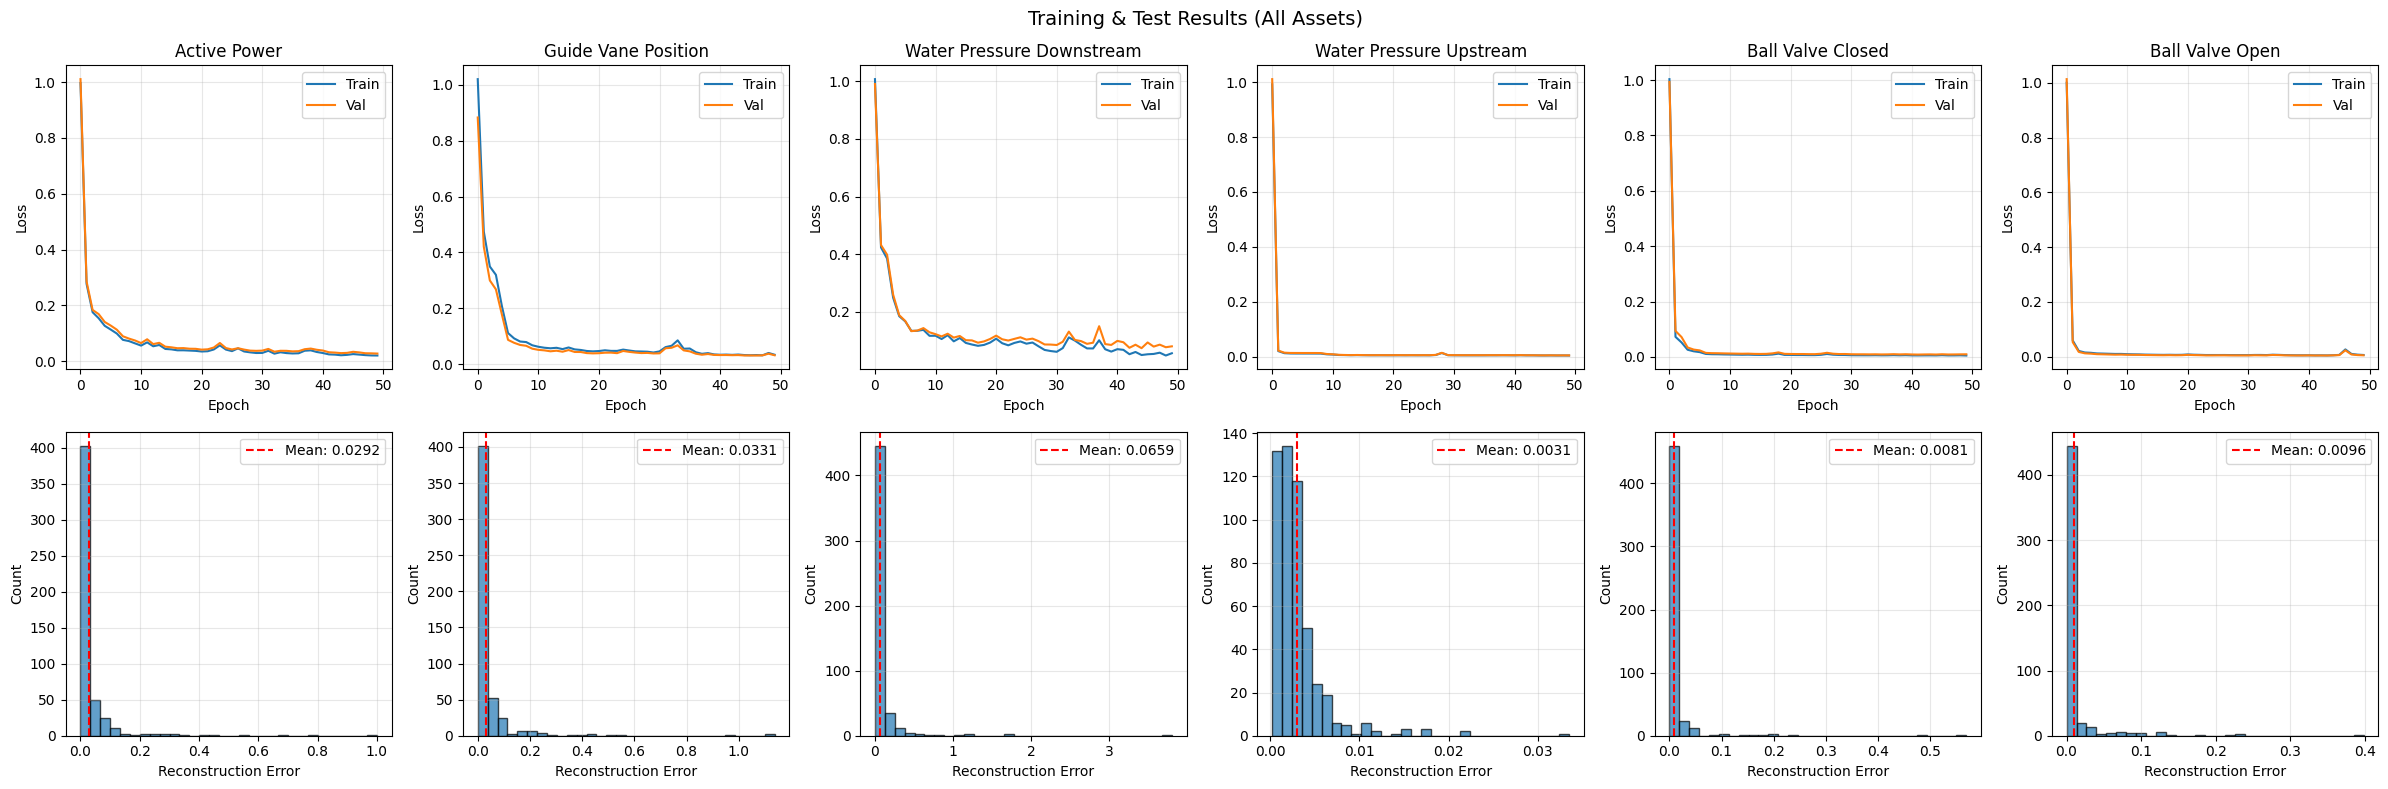


METRICS (All Assets)
active_power: Mean=0.0292, Std=0.0857, Min=0.0001, Max=1.0018, Median=0.0025
guide_vane_position: Mean=0.0331, Std=0.1054, Min=0.0001, Max=1.1373, Median=0.0011
water_pressure_downstream: Mean=0.0659, Std=0.2396, Min=0.0005, Max=3.8011, Median=0.0061
water_pressure_upstream: Mean=0.0031, Std=0.0031, Min=0.0002, Max=0.0335, Median=0.0023
ball_valve_closed: Mean=0.0081, Std=0.0404, Min=0.0001, Max=0.5695, Median=0.0003
ball_valve_open: Mean=0.0096, Std=0.0327, Min=0.0002, Max=0.3984, Median=0.0002


In [52]:
# Visualization: loss curves + metrics
import matplotlib.pyplot as plt

def plot_results(histories, test_errors):
    """Plot loss curves and error distributions."""
    sigs = list(histories.keys())
    fig, axes = plt.subplots(2, len(sigs), figsize=(4*len(sigs), 8))
    
    for i, sig in enumerate(sigs):
        # Loss curves
        axes[0, i].plot(histories[sig]['train'], label='Train')
        axes[0, i].plot(histories[sig]['val'], label='Val')
        axes[0, i].set_title(sig.replace('_', ' ').title())
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        
        # Error histogram
        axes[1, i].hist(test_errors[sig], bins=30, alpha=0.7, edgecolor='black')
        axes[1, i].axvline(np.mean(test_errors[sig]), color='r', linestyle='--', label=f'Mean: {np.mean(test_errors[sig]):.4f}')
        axes[1, i].set_xlabel('Reconstruction Error')
        axes[1, i].set_ylabel('Count')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    fig.suptitle('Training & Test Results (All Assets)', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print(f"\n{'='*60}\nMETRICS (All Assets)\n{'='*60}")
    for sig in sigs:
        err = test_errors[sig]
        print(f"{sig}: Mean={np.mean(err):.4f}, Std={np.std(err):.4f}, "
              f"Min={np.min(err):.4f}, Max={np.max(err):.4f}, Median={np.median(err):.4f}")

# --- RUN: Train across all assets ---
print("Training 6 autoencoders (1 per signal) across all assets...")
models, scalers, histories = train_autoencoders_all_assets(
    results, 
    epochs=50, 
    batch_size=64,
    lr=0.001)

print("\nEvaluating on test set (all assets)...")
test_errors = evaluate_autoencoders_all_assets(models, scalers, results)

plot_results(histories, test_errors)

### 8.2.5. Use HDBSCAN

Extracting latent space...

Fitting HDBSCAN on training latent space...


/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.v

active_power: 2 clusters, 392 noise points
guide_vane_position: 2 clusters, 375 noise points
water_pressure_downstream: 2 clusters, 329 noise points
water_pressure_upstream: 0 clusters, 644 noise points
ball_valve_closed: 2 clusters, 35 noise points


/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.v

ball_valve_open: 3 clusters, 10 noise points
combined: 3 clusters, 248 noise points

Flagging anomalies in test data...
active_power: 72/109 anomalies flagged
guide_vane_position: 66/109 anomalies flagged
water_pressure_downstream: 61/109 anomalies flagged
water_pressure_upstream: 109/109 anomalies flagged
ball_valve_closed: 109/109 anomalies flagged
ball_valve_open: 109/109 anomalies flagged
combined: 32/109 anomalies flagged

ANOMALY DETECTION SUMMARY

active_power:
  Total: 109, Anomalies: 72
    low_prob: 72
    noise: 72
    normal: 37

guide_vane_position:
  Total: 109, Anomalies: 66
    low_prob: 66
    noise: 66
    normal: 43

water_pressure_downstream:
  Total: 109, Anomalies: 61
    low_prob: 61
    noise: 61
    normal: 48

water_pressure_upstream:
  Total: 109, Anomalies: 109
    low_prob: 109
    noise: 109

ball_valve_closed:
  Total: 109, Anomalies: 109
    low_prob: 109
    noise: 7

ball_valve_open:
  Total: 109, Anomalies: 109
    low_prob: 109
    noise: 2

combined

/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/hdbscan/prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'


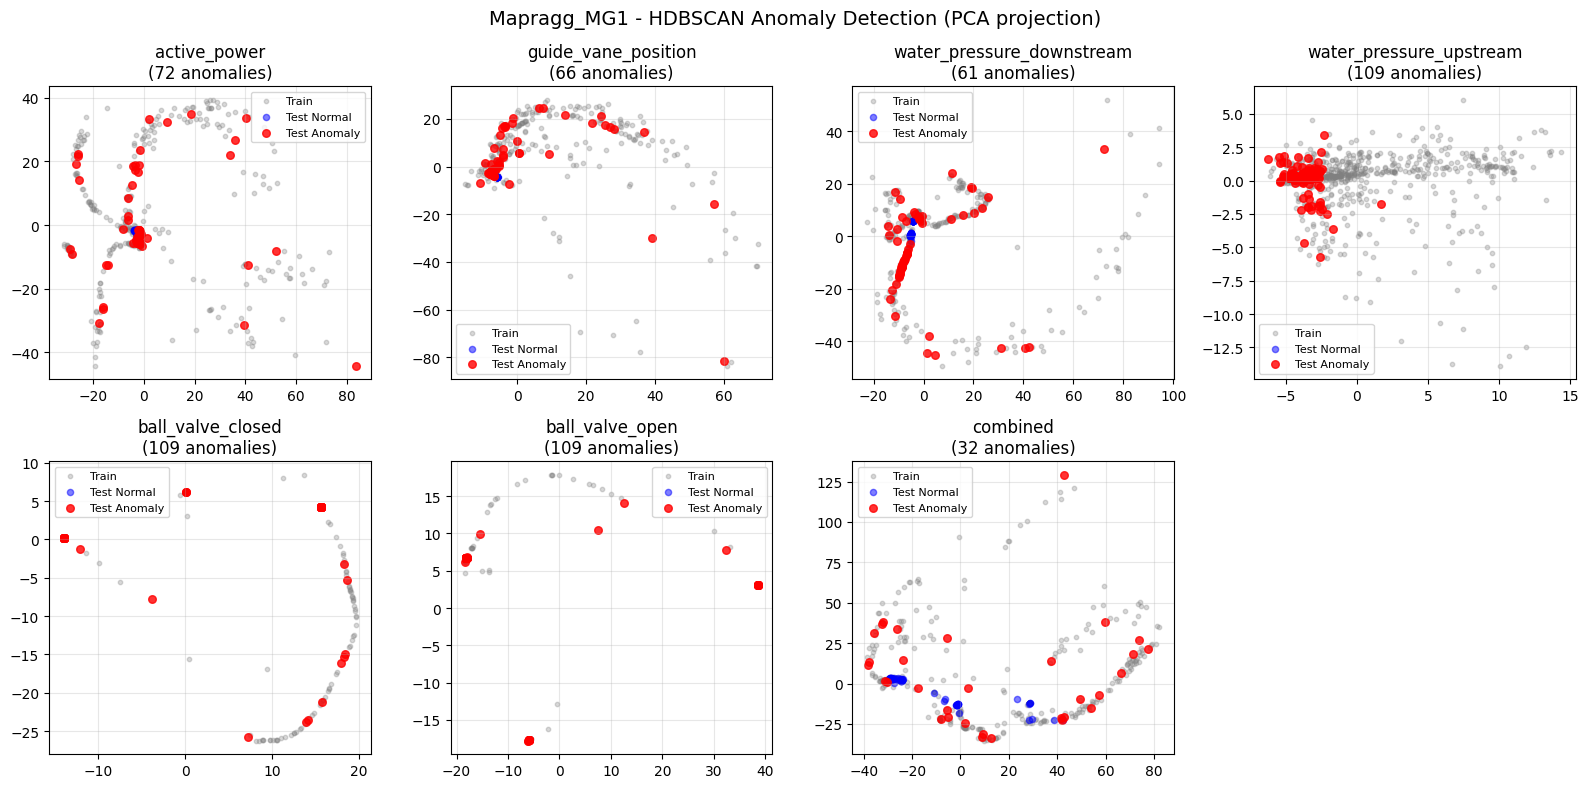

In [53]:
# Run HDBSCAN anomaly detection
# (Assumes models, scalers already trained from previous cell)

# Extract latent representations
print("Extracting latent space...")
latent_train = extract_latent(models, scalers, results[train_key])
latent_test = extract_latent(models, scalers, results[test_key])

# Fit HDBSCAN on training data
print("\nFitting HDBSCAN on training latent space...")
clusterers = fit_hdbscan(latent_train, min_cluster_ratio=0.1)

# Flag anomalies in test data
print("\nFlagging anomalies in test data...")
flags = flag_anomalies(clusterers, latent_train, latent_test, prob_threshold=0.1, small_cluster_threshold=0.05)

# Summary
summarize_anomalies(flags)

# Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, key in enumerate(flags.keys()):
    if i >= len(axes): break
    ax = axes[i]
    
    # Get latent space
    if key == 'combined':
        Z_train = np.hstack([latent_train[s] for s in sorted(latent_train.keys())])
        Z_test = np.hstack([latent_test[s] for s in sorted(latent_test.keys())])
    else:
        Z_train, Z_test = latent_train[key], latent_test[key]
    
    # PCA for visualization
    pca = PCA(n_components=2)
    Z_all = np.vstack([Z_train, Z_test])
    Z_2d = pca.fit_transform(Z_all)
    Z_train_2d, Z_test_2d = Z_2d[:len(Z_train)], Z_2d[len(Z_train):]
    
    # Plot
    ax.scatter(Z_train_2d[:, 0], Z_train_2d[:, 1], c='gray', alpha=0.3, s=10, label='Train')
    ax.scatter(Z_test_2d[~flags[key]['is_anomaly'], 0], Z_test_2d[~flags[key]['is_anomaly'], 1], 
               c='blue', alpha=0.5, s=20, label='Test Normal')
    ax.scatter(Z_test_2d[flags[key]['is_anomaly'], 0], Z_test_2d[flags[key]['is_anomaly'], 1], 
               c='red', alpha=0.8, s=30, label='Test Anomaly')
    ax.set_title(f"{key}\n({flags[key]['n_anomalies']} anomalies)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(len(flags), len(axes)):
    axes[i].axis('off')

plt.suptitle(f'{ASSET_BASE} - HDBSCAN Anomaly Detection (PCA projection)', fontsize=14)
plt.tight_layout()
plt.show()

